# PSO-AFW-CIL Quick Test — 3 Kịch bản trên 1 Tập dữ liệu nhỏ

Dùng dataset **haberman** (haberman.csv) cho cả 3 kịch bản:

| KB | Mô tả |
|---|---|
| **KB1** | W-SVM vs AFW-CIL-fixed vs GridSearch-AFW-CIL vs PSO-AFW-CIL |
| **KB2** | 6-cấu hình hybrid pipeline (± BL-SMOTE) |
| **KB3** | Stress-test IR bằng `change_rate_data` (7 mức IR từ 20% → 2%) |

Mỗi lần chạy tạo thư mục `./Experiment/Test_DDMMYYYY_HHMMSS/` riêng.  
Các file CSV được lưu dần sau mỗi fold (không mất khi crash).


## Cell 1 — Imports & Môi trường

In [1]:
import sys, os, math, csv, time, tracemalloc, glob
import numpy as np
import pandas as pd
from datetime import datetime

# ── sys.path ──────────────────────────────────────────────────
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(f"sys.path += {parent_dir}")

# ── sklearn ───────────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (confusion_matrix, roc_auc_score, f1_score,
                              accuracy_score, classification_report)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split as tts

# ── imbalanced-learn ──────────────────────────────────────────
from imblearn.over_sampling import BorderlineSMOTE

# ── project modules ───────────────────────────────────────────
from wsvm.application import Wsvm
from svm.application import Svm
from fuzzy.weight import fuzzy
from data.common.change_rate_data import change_rate_data

# ── Matplotlib ────────────────────────────────────────────────
import matplotlib.pyplot as plt

# ── Timestamp của lần chạy (dùng sau khi biết tên dataset) ───
_RUN_TS = datetime.now().strftime("%d%m%Y_%H%M%S")

print("✔ Imports OK")
print(f"✔ Run timestamp: {_RUN_TS}")


sys.path += /home/quangvd/project/FAIR-2022
✔ Imports OK
✔ Run timestamp: 13032026_003243


## Cell 2 — Tải & Tiền xử lý Dataset

In [2]:
# ── Cấu hình dataset (chỉ cần đổi ở đây để thử dataset khác) ─
DATASET_NAME = "haberman"       # << đổi tên dataset tại đây
DATASET_FILE = "/home/quangvd/project/FAIR-2022/Processing_Data/dataset/haberman.csv"
LABEL_COL    = "class"
LABEL_MAP    = {2: 1.0, 1: -1.0}   # lớp thiểu số (2) → +1
DROP_COLS    = []
CAT_COLS     = []
IMPUTE       = False

# ── Tên file dataset (không extension) → dùng đặt tên thư mục & kết quả ──
_DS_BASE = os.path.splitext(os.path.basename(DATASET_FILE))[0]   # vd: "haberman"

# ── Tạo thư mục lưu kết quả: Experiment/Test_{tên_file}_{timestamp}/ ─────
RUN_DIR = os.path.join("./Experiment", f"Test_{_DS_BASE}_{_RUN_TS}")
LOG_DIR = os.path.join(RUN_DIR, "logs")
os.makedirs(RUN_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
print(f"✔ Thư mục lần chạy: {RUN_DIR}")

# ── Tham số chạy nhanh (nhỏ để test) ─────────────────────────
N_SPLITS      = 5       # số fold CV
N_REPEATS     = 10       # số lần lặp
PSO_PARTICLES = 5       # số hạt PSO
PSO_ITERS     = 20       # số vòng PSO
C             = 100
T_INNER       = 5       # số vòng LFB inner
NAMEMETHOD    = "distance_center_own_opposite_tam"
NAMEFUNCTION  = "func_own_opp_new"
BOUNDS        = [(3, 11), (0.01, 0.5), (0.01, 0.99), (0.01, 0.5), (0.01, 0.99)]

# ── Đọc file ─────────────────────────────────────────────────
df_raw = pd.read_csv(DATASET_FILE)
print(f"Raw shape : {df_raw.shape}")
print(f"Columns   : {df_raw.columns.tolist()}")

# Label mapping
df_raw[LABEL_COL] = df_raw[LABEL_COL].map(LABEL_MAP)
df_raw = df_raw.dropna(subset=[LABEL_COL])

y_all = df_raw[LABEL_COL].values.astype(float)
X_df  = df_raw.drop(columns=[LABEL_COL] + DROP_COLS)

# Categorical encoding
if CAT_COLS:
    cat_idx = [X_df.columns.get_loc(c) for c in CAT_COLS]
    ct = ColumnTransformer(
        [('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_idx)],
        remainder='passthrough')
    X_all = np.array(ct.fit_transform(X_df.values), dtype=float)
else:
    X_all = X_df.values.astype(float)

# Imputation
if IMPUTE:
    X_all = SimpleImputer(strategy='mean').fit_transform(X_all)

# Class distribution
pos_count = int(np.sum(y_all == 1.0))
neg_count = int(np.sum(y_all == -1.0))
ir_natural = pos_count / len(y_all)
print(f"\nTổng mẫu  : {len(y_all)}")
print(f"Lớp +1    : {pos_count}  ({100*pos_count/len(y_all):.1f}%)")
print(f"Lớp -1    : {neg_count}  ({100*neg_count/len(y_all):.1f}%)")
print(f"IR (pos)  : {ir_natural:.4f}")

# ── Lưu checkpoint dataset đã làm sạch ───────────────────────
df_clean = pd.DataFrame(X_all)
df_clean['label'] = y_all
checkpoint_path = os.path.join(RUN_DIR, f"Test_{_DS_BASE}_dataset_cleaned.csv")
df_clean.to_csv(checkpoint_path, index=False)
print(f"\n✔ Đã lưu dataset sạch: {checkpoint_path}")


✔ Thư mục lần chạy: ./Experiment/Test_haberman_13032026_003243
Raw shape : (306, 4)
Columns   : ['att1', 'att2', 'att3', 'class']

Tổng mẫu  : 306
Lớp +1    : 81  (26.5%)
Lớp -1    : 225  (73.5%)
IR (pos)  : 0.2647

✔ Đã lưu dataset sạch: ./Experiment/Test_haberman_13032026_003243/Test_haberman_dataset_cleaned.csv


## Cell 3 — Wrappers Phân loại Cơ sở & Hàm Tiện ích

In [3]:
# ── Wrappers ─────────────────────────────────────────────────
def svm_lib(X_train, y_train, X_test):
    return SVC(probability=True, kernel='linear').fit(X_train, y_train).predict(X_test)

def wsvm(C, X_train, y_train, X_test, distribution_weight=None):
    m = Wsvm(C, distribution_weight)
    m.fit(X_train, y_train)
    return m.predict(X_test)

def svm(C, X_train, y_train, X_test):
    m = Svm(C)
    m.fit(X_train, y_train)
    return m.predict(X_test)


# ── Tomek Links ───────────────────────────────────────────────
def is_tomek(X, y, class_type):
    nn = NearestNeighbors(n_neighbors=2)
    nn.fit(X)
    _, nbr = nn.kneighbors(X)
    nn_idx = nbr[:, 1]
    links = np.zeros(len(y), dtype=bool)
    excluded = [c for c in np.unique(y) if c not in class_type]
    X_dangxet, X_tl = [], []
    for i, tgt in enumerate(y):
        if tgt in excluded:
            continue
        if y[nn_idx[i]] != tgt and nn_idx[nn_idx[i]] == i:
            X_tl.append(i)
            X_dangxet.append(nn_idx[i])
            links[i] = True
    return links, X_dangxet, X_tl


# ── G-mean (safe 2×2 CM) ─────────────────────────────────────
def Gmean(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred, labels=[-1.0, 1.0])
    TN, FP, FN, TP = cm.ravel()
    SE = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    SP = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    return SP, SE, math.sqrt(SE * SP)


# ── CSV helpers ───────────────────────────────────────────────
CSV_HEADER = ['Times', 'Fold', 'T', 'Name Method', 'Name Function',
              'SP', 'SE', 'Gmean', 'F1 Score', 'Accuracy', 'AUC', 'Confusion Matrix']

def append_csv_row(filepath, row):
    write_header = not os.path.exists(filepath)
    with open(filepath, 'a', encoding='UTF8', newline='') as f:
        w = csv.writer(f)
        if write_header:
            w.writerow(CSV_HEADER)
        w.writerow(row)

def make_row(times, fold, t_iter, namemethod, namefunction,
             sp, se, gm, f1, acc, auc, cm_str):
    return [times, fold, t_iter, namemethod, namefunction,
            round(float(sp), 4), round(float(se), 4), round(float(gm), 4),
            round(float(f1), 4), round(float(acc), 4), round(float(auc), 4),
            cm_str]


# ── Ghi metrics vào file text ─────────────────────────────────
def metr_text(f, X_train, y_test, pred, sp, se, gm):
    f.write(f"\nTrain={len(X_train)} | Test={len(y_test)}\n")
    f.write(classification_report(y_test, pred, zero_division=0))
    f.write(f"SP={sp:.4f} | SE={se:.4f} | Gmean={gm:.4f} | "
            f"F1={f1_score(y_test, pred, zero_division=0):.4f} | "
            f"Acc={accuracy_score(y_test, pred):.4f} | "
            f"AUC={roc_auc_score(y_test, pred):.4f}\n")


print("✔ Wrappers & utility functions OK")


✔ Wrappers & utility functions OK


## Cell 4 — Fuzzy Weight (CalFW) + AFW-CIL Core + LFB + PSO + GridSearch

In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║  FUZZY WEIGHT – CalFW                                    ║
# ╚══════════════════════════════════════════════════════════╝
def compute_weight(X, y,
                   name_method="distance_center_own_opposite_tam",
                   name_function="func_own_opp_new",
                   beta=None, C=None, gamma=None, u=None, sigma=None):
    method   = fuzzy.method()
    function = fuzzy.function()
    pos_index = np.where(y == 1)[0]
    neg_index = np.where(y == -1)[0]
    if name_method == "own_class_center":
        d = method.own_class_center(X, y)
    elif name_method == "estimated_hyper_lin":
        d = method.estimated_hyper_lin(X, y)
    elif name_method == "own_class_center_opposite":
        d = method.own_class_center_opposite(X, y)
    elif name_method == "actual_hyper_lin":
        d = method.actual_hyper_lin(X, y, C=C, gamma=gamma)
    elif name_method == "own_class_center_divided":
        d = method.own_class_center_divided(X, y)
    elif name_method == "distance_center_own_opposite_tam":
        d_own, d_opp, d_tam = method.distance_center_own_opposite_tam(X, y)
    else:
        raise ValueError(f"Unknown name_method: {name_method}")

    if name_function == "lin":
        W = function.lin(d)
    elif name_function == "exp":
        W = function.exp(d, beta)
    elif name_function == "lin_center_own":
        W = function.lin_center_own(d, pos_index, neg_index)
    elif name_function == "gau":
        W = function.gau(d, u, sigma)
    elif name_function == "func_own_opp_new":
        W = function.func_own_opp_new(d_own, d_opp, pos_index, neg_index, d_tam)
    else:
        raise ValueError(f"Unknown name_function: {name_function}")

    W = np.array(W)
    r_neg = len(pos_index) / max(len(neg_index), 1)
    m = np.zeros(len(y))
    m[pos_index] = W[pos_index] * 1.0
    m[neg_index] = W[neg_index] * r_neg
    return m


def fuzzy_weight(beta_center, beta_estimate, beta_actual,
                 X_train, y_train, namemethod, namefunction):
    beta_map = {
        ("own_class_center_opposite", "exp"): beta_center,
        ("own_class_center",          "exp"): beta_estimate,
        ("own_class_center_divided",  "exp"): beta_estimate,
        ("estimated_hyper_lin",       "exp"): beta_estimate,
        ("actual_hyper_lin",          "exp"): beta_actual,
    }
    beta = beta_map.get((namemethod, namefunction), None)
    return compute_weight(X_train, y_train,
                          name_method=namemethod, name_function=namefunction,
                          beta=beta)


print("✔ Fuzzy weight OK")


✔ Fuzzy weight OK


In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║  AFW-CIL CORE – Fixed & Parametric (Thuật toán 3.2)      ║
# ╚══════════════════════════════════════════════════════════╝
FIXED_RATE = 1.2   # tác giả mã nguồn dùng hằng 1.2 thay cho 4 σ riêng biệt

def data_tomelinks_final(C, ind_posX, ind_negX, weight,
                          X_test, y_test, X_train, y_train, K_neighbors):
    """
    Phiên bản cố định (σ = FIXED_RATE = 1.2) của Thuật toán 3.2 AdjFW.
    Tác giả mã nguồn gốc hardcode 1.2 thay vì tìm kiếm σ1~σ4 riêng.
    Ánh xạ tương đương:
      /FIXED_RATE  ≈  *(1 - σ)  hoặc  *σ_tắt   (giảm trọng số)
      *FIXED_RATE  ≈  *(1 + σ)                  (tăng trọng số)
    """
    new_W   = np.copy(weight)
    neg_idx = np.where(y_train == -1)[0]
    clf = Wsvm(C, new_W)
    clf.fit(X_train, y_train)
    y_predict = clf.predict(X_test)
    # Guard: NaN trong y_predict (do weight NaN khi IR quá thấp)
    if np.any(np.isnan(y_predict)):
        return new_W, 0.0, 0.0
    _, se, gm = Gmean(y_test, y_predict)

    nn2 = NearestNeighbors(n_neighbors=K_neighbors)
    nn2.fit(X_train)

    # Batch predict toàn bộ tập train một lần (Fix B)
    all_train_preds = clf.predict(X_train)

    # Giảm trọng số các mẫu âm bị phân loại sai (xấp xỉ dòng 11: m-_j *= σ2)
    wrong = np.where(all_train_preds[neg_idx] != -1.0)[0]
    new_W[neg_idx[wrong]] /= FIXED_RATE     # ≈ m-_j *= σ2  (dòng 11)

    ind_nn, y_nn = [], []
    for ind, i in enumerate(ind_posX):
        if all_train_preds[i] == -1.0:
            # ht(xi) = -1  →  chuẩn bị xử lý Case 2 (dòng 12-16)
            ind_nn.append(ind)
            for j in nn2.kneighbors(X_train[i:i+1])[1].flatten():
                y_nn.append(y_train[j])
        else:
            # ht(xi) = +1  →  Case 1 (dòng 7-9)
            new_W[ind_negX[ind]] /= FIXED_RATE   # dòng 9 : m-_j *= (1-σ1)
            new_W[i]             *= FIXED_RATE   # dòng 8 : m+_i *= (1+σ1)

    if len(y_nn) > 0:
        y_nn = np.array_split(np.array(y_nn), max(1, len(y_nn) // K_neighbors))
        for ind_k, _ in enumerate(y_nn):
            if 1 not in y_nn[ind_k][1:]:
                # hKNN(xik) = -1 → dòng 15-16: m+_i *= σ4
                new_W[ind_posX[ind_nn[ind_k]]] /= FIXED_RATE   # ≈ *σ4
            else:
                # có láng giềng +1 → dòng 13-14: σ3
                new_W[ind_negX[ind_nn[ind_k]]] /= FIXED_RATE   # dòng 14: m-_j *= (1-σ3)
                new_W[ind_posX[ind_nn[ind_k]]] *= FIXED_RATE   # dòng 13: m+_i *= (1+σ3)
    return new_W, gm, se


def data_tomelinks_parametric(C, ind_posX, ind_negX, weight,
                               X_test, y_test, X_train, y_train,
                               K_neighbors, sigma_1, sigma_2, sigma_3, sigma_4):
    """
    Triển khai đầy đủ Thuật toán 3.2 – AdjFW với 4 tham số σ1~σ4 và K.
    Đây là hàm được PSO / GridSearch tối ưu tham số.

    Với mỗi cặp Tomek link (xi, xj): yi=+1, yj=-1

    Case 1 — ht(xi)=+1 VÀ ht(xj)=+1  (xi đúng, xj sai):
        m+_i *= (1 + σ1)                           [dòng 8]
        m-_j *= (1 - σ1)                           [dòng 9]
        nếu đa số KNN(xj) dự đoán +1:             [dòng 10]
            m-_j *= σ2                              [dòng 11]

    Case 2 — ht(xi)=-1 VÀ ht(xj)=-1  (xi sai, xj đúng):
        m+_i *= (1 + σ3)                           [dòng 13]
        m-_j *= (1 - σ3)                           [dòng 14]
        nếu đa số KNN(xi) dự đoán -1:             [dòng 15]
            m+_i *= σ4                              [dòng 16]

    Giá trị tham khảo luận án: K=5, σ1=0.1, σ2=0.5, σ3=0.1, σ4=0.5
    """
    new_W = np.copy(weight)
    clf = Wsvm(C, new_W)
    clf.fit(X_train, y_train)
    y_predict = clf.predict(X_test)
    # Guard: NaN trong y_predict (do weight NaN khi IR quá thấp)
    if np.any(np.isnan(y_predict)):
        return new_W, 0.0, 0.0
    _, se, gm = Gmean(y_test, y_predict)

    nn2 = NearestNeighbors(n_neighbors=K_neighbors)
    nn2.fit(X_train)
    # Batch predict toàn bộ tập train một lần (Fix B)
    all_train_preds = clf.predict(X_train)

    for ind, i in enumerate(ind_posX):
        j_idx = ind_negX[ind]                       # xj (âm, yj=-1)
        ht_xi = all_train_preds[i]                  # ht(xi) — batch
        ht_xj = all_train_preds[j_idx]              # ht(xj) — batch

        if ht_xi == 1.0 and ht_xj == 1.0:
            # ── Case 1: xi đúng (+1), xj sai (+1) ───────────
            new_W[i]     *= (1.0 + sigma_1)                # dòng 8
            new_W[j_idx] *= (1.0 - sigma_1)                # dòng 9

            # hKNN(xjk): kiểm tra đa số KNN của xj có dự đoán +1 không
            knn_j_idx = nn2.kneighbors(X_train[j_idx:j_idx+1])[1].flatten()
            if np.sum(all_train_preds[knn_j_idx] == 1.0) > K_neighbors / 2:  # dòng 10
                new_W[j_idx] *= sigma_2                     # dòng 11

        elif ht_xi == -1.0 and ht_xj == -1.0:
            # ── Case 2: xi sai (-1), xj đúng (-1) ───────────
            new_W[i]     *= (1.0 + sigma_3)                # dòng 13
            new_W[j_idx] *= (1.0 - sigma_3)                # dòng 14

            # hKNN(xik): kiểm tra đa số KNN của xi có dự đoán -1 không
            knn_i_idx = nn2.kneighbors(X_train[i:i+1])[1].flatten()
            if np.sum(all_train_preds[knn_i_idx] == -1.0) > K_neighbors / 2:  # dòng 15
                new_W[i] *= sigma_4                         # dòng 16

        # Các cặp hỗn hợp (ht(xi)≠ht(xj)) không thuộc Case 1 hay Case 2 → bỏ qua

    return new_W, gm, se


# ── LFB Loops ─────────────────────────────────────────────────
def lfb_fixed(C, ind_posX, ind_negX, weight, T, X_test, y_test, X_train, y_train,
              K_neighbors=6):
    gmax, best_w = 0.0, np.copy(weight)
    cur_w = np.copy(weight)
    history = []
    for _ in range(T):
        cur_w, gm, _ = data_tomelinks_final(
            C, ind_posX, ind_negX, cur_w, X_test, y_test, X_train, y_train, K_neighbors)
        history.append(gm)
        if gm > gmax:
            gmax   = gm
            best_w = np.copy(cur_w)
    return best_w, gmax, history


def lfb_pso(C, ind_posX, ind_negX, weight, T,
            X_test, y_test, X_train, y_train,
            K_neighbors, s1, s2, s3, s4):
    gmax, best_w = 0.0, np.copy(weight)
    cur_w = np.copy(weight)
    for _ in range(T):
        cur_w, gm, _ = data_tomelinks_parametric(
            C, ind_posX, ind_negX, cur_w,
            X_test, y_test, X_train, y_train,
            K_neighbors, s1, s2, s3, s4)
        if gm > gmax:
            gmax   = gm
            best_w = np.copy(cur_w)
    return best_w, gmax


print("✔ AFW-CIL (fixed & parametric) + LFB OK")
print("  data_tomelinks_parametric: triển khai đầy đủ Thuật toán 3.2 (K, σ1, σ2, σ3, σ4)")
print("  data_tomelinks_final     : hardcode FIXED_RATE=1.2 (như mã nguồn gốc tác giả)")


✔ AFW-CIL (fixed & parametric) + LFB OK
  data_tomelinks_parametric: triển khai đầy đủ Thuật toán 3.2 (K, σ1, σ2, σ3, σ4)
  data_tomelinks_final     : hardcode FIXED_RATE=1.2 (như mã nguồn gốc tác giả)


In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║  PSO OPTIMIZER                                            ║
# ╚══════════════════════════════════════════════════════════╝
class PSO_AFWCIL:
    def __init__(self, num_particles, iters, bounds, C, T,
                 X_train, y_train, X_test, y_test,
                 namemethod, namefunction):
        self.num_particles = num_particles
        self.iters         = iters
        self.bounds        = bounds
        self.C             = C
        self.T             = T
        self.X_train       = X_train
        self.y_train       = y_train
        self.X_test        = X_test
        self.y_test        = y_test
        self.namemethod    = namemethod
        self.namefunction  = namefunction
        _, self.ind_posX, self.ind_negX = is_tomek(
            X_train, y_train, class_type=[-1.0])
        self.init_weight = fuzzy_weight(
            0.5, 0.8, 0.2, X_train, y_train, namemethod, namefunction)
        # Guard: NaN/âm xảy ra khi lớp thiểu số quá ít mẫu (IR rất thấp)
        if np.any(np.isnan(self.init_weight)) or np.any(self.init_weight <= 0):
            self.init_weight = np.ones(len(y_train))
        self.dim = len(bounds)

    def fitness_function(self, particle):
        K = max(1, int(round(float(particle[0]))))
        s1, s2, s3, s4 = particle[1], particle[2], particle[3], particle[4]
        _, gmax = lfb_pso(
            self.C, self.ind_posX, self.ind_negX, self.init_weight, self.T,
            self.X_test, self.y_test, self.X_train, self.y_train,
            K, s1, s2, s3, s4)
        return gmax

    def optimize(self):
        n, dim = self.num_particles, self.dim
        pos = np.array([[self.bounds[d][0] + np.random.rand()
                         * (self.bounds[d][1] - self.bounds[d][0])
                         for d in range(dim)] for _ in range(n)], dtype=float)
        vel = np.zeros_like(pos)
        pbest_pos = pos.copy()
        pbest_val = np.array([self.fitness_function(pos[i]) for i in range(n)])
        gbest_idx = int(np.argmax(pbest_val))
        gbest_pos = pbest_pos[gbest_idx].copy()
        gbest_val = float(pbest_val[gbest_idx])
        convergence = []
        w, c1, c2 = 0.7, 1.5, 1.5
        for _ in range(self.iters):
            for i in range(n):
                r1, r2 = np.random.rand(dim), np.random.rand(dim)
                vel[i] = (w * vel[i]
                          + c1 * r1 * (pbest_pos[i] - pos[i])
                          + c2 * r2 * (gbest_pos    - pos[i]))
                pos[i] = np.clip(pos[i] + vel[i],
                                 [b[0] for b in self.bounds],
                                 [b[1] for b in self.bounds])
                fval = self.fitness_function(pos[i])
                if fval > pbest_val[i]:
                    pbest_val[i] = fval
                    pbest_pos[i] = pos[i].copy()
                if fval > gbest_val:
                    gbest_val = fval
                    gbest_pos = pos[i].copy()
            convergence.append(gbest_val)
        return gbest_pos, gbest_val, convergence


# ── GridSearch baseline ───────────────────────────────────────
def grid_search_afwcil(C, T, X_train, y_train, X_test, y_test,
                        namemethod, namefunction,
                        K_grid=None, sigma_grid=None):
    if K_grid     is None: K_grid     = [3, 5, 7, 9, 11]
    if sigma_grid is None: sigma_grid = [0.1, 0.2, 0.3, 0.5]
    _, ind_posX, ind_negX = is_tomek(X_train, y_train, class_type=[-1.0])
    init_w = fuzzy_weight(0.5, 0.8, 0.2, X_train, y_train, namemethod, namefunction)
    best_gmean, best_params = -1.0, {}
    t0 = time.time()
    for K in K_grid:
        for sigma in sigma_grid:
            _, gmax = lfb_pso(C, ind_posX, ind_negX, init_w, T,
                               X_test, y_test, X_train, y_train,
                               K, sigma, sigma, sigma, sigma)
            if gmax > best_gmean:
                best_gmean  = gmax
                best_params = {"K": K, "sigma": sigma}
    return best_params, best_gmean, round(time.time() - t0, 4)



print("✔ PSO_AFWCIL class + grid_search_afwcil OK")

✔ PSO_AFWCIL class + grid_search_afwcil OK


---
## Kịch bản 1 (KB1) — So sánh 4 phương pháp trên cùng dataset

| # | Phương pháp | Ghi chú |
|---|---|---|
| 1 | **W-SVM** | Baseline |
| 2 | **AFW-CIL (fixed σ=1.2)** | Tác giả nguồn dùng hằng 1.2 thay toàn bộ σ1~σ4; K=6 |
| 3 | **GridSearch-AFW-CIL** | Duyệt K × σ (dùng σ1=σ2=σ3=σ4=σ đồng nhất) |
| 4 | **PSO-AFW-CIL** | PSO tối ưu {K, σ₁, σ₂, σ₃, σ₄} theo Thuật toán 3.2 |

**Thuật toán 3.2 — AdjFW:** 5 tham số tìm kiếm: K, σ1, σ2, σ3, σ4  
Giá trị tham khảo luận án: K=5, σ₁=σ₃=0.1, σ₂=σ₄=0.5


In [7]:
def run_kb1(X_all, y_all, run_dir, dataset_name=_DS_BASE):
    """
    KB1: So sánh W-SVM / AFW-CIL-fixed / GridSearch / PSO-AFW-CIL.
    Mỗi phương pháp bọc try/except độc lập — lỗi 1 phương pháp không dừng fold.
    Trả về: (csv_path, df_summary)
    """
    ts       = datetime.now().strftime("%d%m%Y_%H%M%S")
    csv_path = os.path.join(run_dir, f"Test_{dataset_name}_KB1_{ts}.csv")

    def _safe_auc(y_true, y_pred):
        try:
            return roc_auc_score(y_true, y_pred)
        except ValueError:
            return float('nan')

    print(f"\n{'='*60}")
    print(f"KB1 | Dataset: {dataset_name} | {N_REPEATS}×{N_SPLITS}-fold CV")
    print(f"Output: {csv_path}")
    print(f"{'='*60}")

    for rep in range(1, N_REPEATS + 1):
        skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=rep * 7)
        for fold, (tr_idx, te_idx) in enumerate(skf.split(X_all, y_all), 1):
            X_tr_raw, X_te_raw = X_all[tr_idx], X_all[te_idx]
            y_tr, y_te         = y_all[tr_idx], y_all[te_idx]

            sc   = StandardScaler()
            X_tr = sc.fit_transform(X_tr_raw)
            X_te = sc.transform(X_te_raw)

            # Guard: fold suy biến (không xảy ra trên haberman đầy đủ, nhưng an toàn)
            if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
                print(f"  [!] Rep {rep:02d} | Fold {fold} | <2 lớp → bỏ qua fold")
                continue

            # ── 1. W-SVM ──────────────────────────────────────────
            t0 = time.time()
            try:
                pred = wsvm(C, X_tr, y_tr, X_te, np.ones(len(y_tr)))
                sp, se, gm = Gmean(y_te, pred)
                append_csv_row(csv_path, make_row(
                    rep, fold, round(time.time()-t0, 4),
                    "W-SVM", "baseline",
                    sp, se, gm,
                    f1_score(y_te, pred, pos_label=1, zero_division=0),
                    accuracy_score(y_te, pred), _safe_auc(y_te, pred),
                    str(confusion_matrix(y_te, pred, labels=[-1., 1.]).tolist())))
            except Exception as e:
                print(f"  [!] W-SVM lỗi Rep {rep:02d} Fold {fold}: {e}")
                append_csv_row(csv_path, make_row(
                    rep, fold, round(time.time()-t0, 4),
                    "W-SVM", "ERROR", 0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))

            # ── 2. AFW-CIL (σ=1.2) ───────────────────────────────
            t0 = time.time()
            try:
                _, posX, negX = is_tomek(X_tr, y_tr, class_type=[-1.0])
                w_init = fuzzy_weight(0.5, 0.8, 0.2, X_tr, y_tr, NAMEMETHOD, NAMEFUNCTION)
                if np.any(np.isnan(w_init)) or np.any(w_init <= 0):
                    w_init = np.ones(len(y_tr))
                best_w, _, _ = lfb_fixed(C, posX, negX, w_init, T_INNER, X_te, y_te, X_tr, y_tr)
                pred = wsvm(C, X_tr, y_tr, X_te, best_w)
                if np.any(np.isnan(pred)):
                    raise ValueError("NaN in AFW-CIL pred")
                sp, se, gm = Gmean(y_te, pred)
                append_csv_row(csv_path, make_row(
                    rep, fold, round(time.time()-t0, 4),
                    "AFW-CIL_fixed", "fixed_sigma_1.2",
                    sp, se, gm,
                    f1_score(y_te, pred, pos_label=1, zero_division=0),
                    accuracy_score(y_te, pred), _safe_auc(y_te, pred),
                    str(confusion_matrix(y_te, pred, labels=[-1., 1.]).tolist())))
            except Exception as e:
                print(f"  [!] AFW-CIL_fixed lỗi Rep {rep:02d} Fold {fold}: {e}")
                append_csv_row(csv_path, make_row(
                    rep, fold, round(time.time()-t0, 4),
                    "AFW-CIL_fixed", "ERROR", 0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))

            # ── 3. GridSearch-AFW-CIL ────────────────────────────
            t0 = time.time()
            try:
                best_p, _, _ = grid_search_afwcil(
                    C, T_INNER, X_tr, y_tr, X_te, y_te, NAMEMETHOD, NAMEFUNCTION,
                    K_grid=[3, 5, 7, 9], sigma_grid=[0.1, 0.3, 0.5])
                if not best_p:
                    raise ValueError("grid_search trả về best_params rỗng")
                _, posX, negX = is_tomek(X_tr, y_tr, class_type=[-1.0])
                w_init = fuzzy_weight(0.5, 0.8, 0.2, X_tr, y_tr, NAMEMETHOD, NAMEFUNCTION)
                if np.any(np.isnan(w_init)) or np.any(w_init <= 0):
                    w_init = np.ones(len(y_tr))
                s = best_p["sigma"]
                best_w, _ = lfb_pso(C, posX, negX, w_init, T_INNER,
                                     X_te, y_te, X_tr, y_tr,
                                     best_p["K"], s, s, s, s)
                pred = wsvm(C, X_tr, y_tr, X_te, best_w)
                if np.any(np.isnan(pred)):
                    raise ValueError("NaN in GridSearch pred")
                sp, se, gm = Gmean(y_te, pred)
                append_csv_row(csv_path, make_row(
                    rep, fold, round(time.time()-t0, 4),
                    "GridSearch-AFW-CIL", f"K={best_p['K']},s={best_p['sigma']}",
                    sp, se, gm,
                    f1_score(y_te, pred, pos_label=1, zero_division=0),
                    accuracy_score(y_te, pred), _safe_auc(y_te, pred),
                    str(confusion_matrix(y_te, pred, labels=[-1., 1.]).tolist())))
            except Exception as e:
                print(f"  [!] GridSearch lỗi Rep {rep:02d} Fold {fold}: {e}")
                append_csv_row(csv_path, make_row(
                    rep, fold, round(time.time()-t0, 4),
                    "GridSearch-AFW-CIL", "ERROR", 0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))

            # ── 4. PSO-AFW-CIL ───────────────────────────────────
            t0 = time.time()
            try:
                pso = PSO_AFWCIL(
                    PSO_PARTICLES, PSO_ITERS, BOUNDS, C, T_INNER,
                    X_tr, y_tr, X_te, y_te, NAMEMETHOD, NAMEFUNCTION)
                gbest_pos, gbest_val, _ = pso.optimize()
                K_b = int(round(float(gbest_pos[0])))
                # Fix C: pso đã tính ind_posX/negX/init_weight → dùng lại
                best_w, _ = lfb_pso(C, pso.ind_posX, pso.ind_negX, pso.init_weight,
                                     T_INNER, X_te, y_te, X_tr, y_tr,
                                     K_b, gbest_pos[1], gbest_pos[2],
                                     gbest_pos[3], gbest_pos[4])
                pred = wsvm(C, X_tr, y_tr, X_te, best_w)
                if np.any(np.isnan(pred)):
                    raise ValueError("NaN in PSO pred")
                sp, se, gm = Gmean(y_te, pred)
                fn_str = (f"K={K_b},s1={gbest_pos[1]:.3f},s2={gbest_pos[2]:.3f},"
                          f"s3={gbest_pos[3]:.3f},s4={gbest_pos[4]:.3f}")
                append_csv_row(csv_path, make_row(
                    rep, fold, round(time.time()-t0, 4),
                    "PSO-AFW-CIL", fn_str,
                    sp, se, gm,
                    f1_score(y_te, pred, pos_label=1, zero_division=0),
                    accuracy_score(y_te, pred), _safe_auc(y_te, pred),
                    str(confusion_matrix(y_te, pred, labels=[-1., 1.]).tolist())))
                print(f"  Rep {rep:02d} | Fold {fold} | PSO Gmean={gbest_val:.3f}")
            except Exception as e:
                print(f"  [!] PSO lỗi Rep {rep:02d} Fold {fold}: {e}")
                append_csv_row(csv_path, make_row(
                    rep, fold, round(time.time()-t0, 4),
                    "PSO-AFW-CIL", "ERROR", 0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))

    # ── Tóm tắt KB1 ──────────────────────────────────────────
    df_kb1 = pd.read_csv(csv_path)
    for col in ['SP', 'SE', 'Gmean', 'F1 Score', 'Accuracy', 'AUC']:
        df_kb1[col] = pd.to_numeric(df_kb1[col], errors='coerce')
    # Loại bỏ hàng ERROR trước khi tính thống kê
    df_kb1_valid = df_kb1[df_kb1["Name Function"] != "ERROR"]
    agg = {}
    for m in ['Gmean', 'SE', 'SP', 'F1 Score', 'AUC']:
        agg[f"{m}_mean"] = (m, 'mean')
        agg[f"{m}_std"]  = (m, 'std')
    df_sum1 = df_kb1_valid.groupby("Name Method").agg(**agg).reset_index()

    sum_path = os.path.join(run_dir, f"Test_{dataset_name}_KB1_summary_{ts}.csv")
    df_sum1.to_csv(sum_path, index=False)

    print(f"\n✔ KB1 xong. CSV: {csv_path}")
    print(f"✔ Tổng hợp  : {sum_path}")
    print(df_sum1[["Name Method", "Gmean_mean", "Gmean_std", "SE_mean"]].to_string(index=False))
    return csv_path, df_sum1


# ── Chạy KB1 ─────────────────────────────────────────────────
csv_kb1, df_kb1_sum = run_kb1(X_all, y_all, RUN_DIR)



KB1 | Dataset: haberman | 10×5-fold CV
Output: ./Experiment/Test_haberman_13032026_003243/Test_haberman_KB1_13032026_003326.csv
  Rep 01 | Fold 1 | PSO Gmean=0.539
  Rep 01 | Fold 2 | PSO Gmean=0.527
  Rep 01 | Fold 3 | PSO Gmean=0.514
  Rep 01 | Fold 4 | PSO Gmean=0.806
  Rep 01 | Fold 5 | PSO Gmean=0.534
  Rep 02 | Fold 1 | PSO Gmean=0.553
  Rep 02 | Fold 2 | PSO Gmean=0.716
  Rep 02 | Fold 3 | PSO Gmean=0.667
  Rep 02 | Fold 4 | PSO Gmean=0.514
  Rep 02 | Fold 5 | PSO Gmean=0.632
  Rep 03 | Fold 1 | PSO Gmean=0.695
  Rep 03 | Fold 2 | PSO Gmean=0.632
  Rep 03 | Fold 3 | PSO Gmean=0.742
  Rep 03 | Fold 4 | PSO Gmean=0.577
  Rep 03 | Fold 5 | PSO Gmean=0.527
  Rep 04 | Fold 1 | PSO Gmean=0.485
  Rep 04 | Fold 2 | PSO Gmean=0.641
  Rep 04 | Fold 3 | PSO Gmean=0.667
  Rep 04 | Fold 4 | PSO Gmean=0.527
  Rep 04 | Fold 5 | PSO Gmean=0.575
  Rep 05 | Fold 1 | PSO Gmean=0.703
  Rep 05 | Fold 2 | PSO Gmean=0.329
  Rep 05 | Fold 3 | PSO Gmean=0.514
  Rep 05 | Fold 4 | PSO Gmean=0.608
  Rep 0

---
## Kịch bản 2 (KB2) — Pipeline Hybrid 6 Mô hình

| # | Phương pháp |
|---|---|
| 1 | W-SVM |
| 2 | BL-SMOTE + W-SVM |
| 3 | AFW-CIL (σ cố định) |
| 4 | PSO-AFW-CIL |
| 5 | BL-SMOTE + AFW-CIL |
| 6 | **BL-SMOTE + PSO-AFW-CIL** ← đề xuất |

CSV + TXT log lưu theo từng repeat vào `{RUN_DIR}/KB2_*`

In [8]:
def run_kb2(X_all, y_all, run_dir, dataset_name=_DS_BASE):
    """
    KB2: 6-cấu hình hybrid pipeline với BL-SMOTE.
    Mỗi phương pháp bọc try/except độc lập — lỗi 1 phương pháp không dừng fold.
    Lưu CSV per-fold + TXT log per-repeat.
    Trả về: (csv_path, txt_path, df_summary)
    """
    ts       = datetime.now().strftime("%d%m%Y_%H%M%S")
    csv_path = os.path.join(run_dir, f"Test_{dataset_name}_KB2_{ts}.csv")
    txt_path = os.path.join(run_dir, "logs", f"Test_{dataset_name}_KB2_{ts}.txt")

    def _safe_auc(y_true, y_pred):
        try:
            return roc_auc_score(y_true, y_pred)
        except ValueError:
            return float('nan')

    def _record(method_name, fn_name, X_use, y_use, w, logf):
        """Chạy W-SVM, ghi CSV + log. Trả về gm (float) hoặc float('nan') nếu lỗi."""
        t0 = time.time()
        try:
            pred = wsvm(C, X_use, y_use, X_te, w)
            if np.any(np.isnan(pred)):
                raise ValueError("NaN trong pred")
            sp, se, gm = Gmean(y_te, pred)
            elapsed = round(time.time() - t0, 4)
            append_csv_row(csv_path, make_row(
                rep, fold, elapsed, method_name, fn_name,
                sp, se, gm,
                f1_score(y_te, pred, pos_label=1, zero_division=0),
                accuracy_score(y_te, pred), _safe_auc(y_te, pred),
                str(confusion_matrix(y_te, pred, labels=[-1., 1.]).tolist())))
            logf.write(f"  {method_name:30s} | Gm={gm:.4f} | AUC={_safe_auc(y_te, pred):.4f} | t={elapsed}s\n")
            return gm
        except Exception as e:
            elapsed = round(time.time() - t0, 4)
            print(f"    [!] {method_name} lỗi Rep {rep:02d} Fold {fold}: {e}")
            append_csv_row(csv_path, make_row(
                rep, fold, elapsed, method_name, f"ERROR|{fn_name}",
                0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))
            logf.write(f"  {method_name:30s} | ERROR: {e}\n")
            return float('nan')

    print(f"\n{'='*60}")
    print(f"KB2 | Dataset: {dataset_name} | {N_REPEATS}×{N_SPLITS}-fold CV")
    print(f"CSV: {csv_path}")
    print(f"{'='*60}")

    with open(txt_path, 'w', encoding='utf-8') as logf:
        logf.write(f"KB2 | Dataset: {dataset_name}\n")
        logf.write(f"Bắt đầu: {datetime.now()}\n\n")

        for rep in range(1, N_REPEATS + 1):
            skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=rep * 7)
            for fold, (tr_idx, te_idx) in enumerate(skf.split(X_all, y_all), 1):
                X_tr_raw, X_te_raw = X_all[tr_idx], X_all[te_idx]
                y_tr, y_te         = y_all[tr_idx], y_all[te_idx]

                sc   = StandardScaler()
                X_tr = sc.fit_transform(X_tr_raw)
                X_te = sc.transform(X_te_raw)

                # Guard: fold suy biến
                if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
                    print(f"  [!] Rep {rep:02d} | Fold {fold} | <2 lớp → bỏ qua fold")
                    logf.write(f"\n--- Rep {rep:02d} | Fold {fold} | SKIPPED (<2 clases) ---\n")
                    continue

                # BL-SMOTE — bọc riêng để nếu SMOTE lỗi vẫn chạy được các phương pháp không dùng SMOTE
                X_tr_sm, y_tr_sm = None, None
                try:
                    sm = BorderlineSMOTE(random_state=rep)
                    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)[:2]
                except Exception as e:
                    print(f"  [!] SMOTE lỗi Rep {rep:02d} Fold {fold}: {e} → các phương pháp dùng SMOTE sẽ ERROR")

                logf.write(f"\n--- Rep {rep:02d} | Fold {fold} ---\n")
                smote_info = f"Train={len(y_tr)} → SMOTE={len(y_tr_sm) if y_tr_sm is not None else 'FAIL'}"
                logf.write(f"  {smote_info}\n")

                # 1. W-SVM
                _record("W-SVM", "baseline", X_tr, y_tr, np.ones(len(y_tr)), logf)

                # 2. BL-SMOTE + W-SVM
                if X_tr_sm is not None:
                    _record("BL-SMOTE+W-SVM", "borderline_smote",
                            X_tr_sm, y_tr_sm, np.ones(len(y_tr_sm)), logf)
                else:
                    append_csv_row(csv_path, make_row(rep, fold, 0.0,
                        "BL-SMOTE+W-SVM", "ERROR|smote_failed",
                        0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))
                    logf.write(f"  {'BL-SMOTE+W-SVM':30s} | SKIP (SMOTE failed)\n")

                # 3. AFW-CIL (fixed σ) — is_tomek + fuzzy_weight tính 1 lần
                t_afw = time.time()
                try:
                    _, posX, negX = is_tomek(X_tr, y_tr, class_type=[-1.0])
                    w_init = fuzzy_weight(0.5, 0.8, 0.2, X_tr, y_tr, NAMEMETHOD, NAMEFUNCTION)
                    if np.any(np.isnan(w_init)) or np.any(w_init <= 0):
                        w_init = np.ones(len(y_tr))
                    best_w, _, _ = lfb_fixed(C, posX, negX, w_init, T_INNER, X_te, y_te, X_tr, y_tr)
                    _record("AFW-CIL_fixed", "fixed_sigma_1.2", X_tr, y_tr, best_w, logf)
                except Exception as e:
                    print(f"    [!] AFW-CIL_fixed setup lỗi Rep {rep:02d} Fold {fold}: {e}")
                    elapsed = round(time.time()-t_afw, 4)
                    append_csv_row(csv_path, make_row(rep, fold, elapsed,
                        "AFW-CIL_fixed", "ERROR", 0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))
                    logf.write(f"  {'AFW-CIL_fixed':30s} | ERROR: {e}\n")

                # 4. PSO-AFW-CIL
                t_pso = time.time()
                try:
                    pso = PSO_AFWCIL(PSO_PARTICLES, PSO_ITERS, BOUNDS, C, T_INNER,
                                     X_tr, y_tr, X_te, y_te, NAMEMETHOD, NAMEFUNCTION)
                    gbpos, gbval, _ = pso.optimize()
                    K_b = int(round(float(gbpos[0])))
                    # Fix C: pso đã tính ind_posX/negX/init_weight → dùng lại
                    best_w, _ = lfb_pso(C, pso.ind_posX, pso.ind_negX, pso.init_weight,
                                         T_INNER, X_te, y_te, X_tr, y_tr,
                                         K_b, gbpos[1], gbpos[2], gbpos[3], gbpos[4])
                    fn_str = (f"K={K_b},s1={gbpos[1]:.3f},s2={gbpos[2]:.3f},"
                              f"s3={gbpos[3]:.3f},s4={gbpos[4]:.3f}")
                    _record("PSO-AFW-CIL", fn_str, X_tr, y_tr, best_w, logf)
                except Exception as e:
                    print(f"    [!] PSO-AFW-CIL lỗi Rep {rep:02d} Fold {fold}: {e}")
                    elapsed = round(time.time()-t_pso, 4)
                    append_csv_row(csv_path, make_row(rep, fold, elapsed,
                        "PSO-AFW-CIL", "ERROR", 0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))
                    logf.write(f"  {'PSO-AFW-CIL':30s} | ERROR: {e}\n")
                    gbval = float('nan')

                # 5. BL-SMOTE + AFW-CIL (fixed)
                if X_tr_sm is not None:
                    t_afw2 = time.time()
                    try:
                        _, posX2, negX2 = is_tomek(X_tr_sm, y_tr_sm, class_type=[-1.0])
                        w_init2 = fuzzy_weight(0.5, 0.8, 0.2, X_tr_sm, y_tr_sm,
                                               NAMEMETHOD, NAMEFUNCTION)
                        if np.any(np.isnan(w_init2)) or np.any(w_init2 <= 0):
                            w_init2 = np.ones(len(y_tr_sm))
                        best_w2, _, _ = lfb_fixed(C, posX2, negX2, w_init2,
                                                   T_INNER, X_te, y_te, X_tr_sm, y_tr_sm)
                        _record("BL-SMOTE+AFW-CIL_fixed", "fixed_sigma_1.2",
                                X_tr_sm, y_tr_sm, best_w2, logf)
                    except Exception as e:
                        print(f"    [!] BL-SMOTE+AFW-CIL setup lỗi Rep {rep:02d} Fold {fold}: {e}")
                        elapsed = round(time.time()-t_afw2, 4)
                        append_csv_row(csv_path, make_row(rep, fold, elapsed,
                            "BL-SMOTE+AFW-CIL_fixed", "ERROR",
                            0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))
                        logf.write(f"  {'BL-SMOTE+AFW-CIL_fixed':30s} | ERROR: {e}\n")
                else:
                    append_csv_row(csv_path, make_row(rep, fold, 0.0,
                        "BL-SMOTE+AFW-CIL_fixed", "ERROR|smote_failed",
                        0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))
                    logf.write(f"  {'BL-SMOTE+AFW-CIL_fixed':30s} | SKIP (SMOTE failed)\n")

                # 6. BL-SMOTE + PSO-AFW-CIL (mô hình đề xuất)
                if X_tr_sm is not None:
                    t_pso2 = time.time()
                    try:
                        pso2 = PSO_AFWCIL(PSO_PARTICLES, PSO_ITERS, BOUNDS, C, T_INNER,
                                          X_tr_sm, y_tr_sm, X_te, y_te,
                                          NAMEMETHOD, NAMEFUNCTION)
                        gbpos2, gbval2, _ = pso2.optimize()
                        K_b2 = int(round(float(gbpos2[0])))
                        # Fix C: pso2 đã tính ind_posX/negX/init_weight → dùng lại
                        best_w2, _ = lfb_pso(C, pso2.ind_posX, pso2.ind_negX, pso2.init_weight,
                                              T_INNER, X_te, y_te, X_tr_sm, y_tr_sm,
                                              K_b2, gbpos2[1], gbpos2[2], gbpos2[3], gbpos2[4])
                        fn_str2 = (f"K={K_b2},s1={gbpos2[1]:.3f},s2={gbpos2[2]:.3f},"
                                   f"s3={gbpos2[3]:.3f},s4={gbpos2[4]:.3f}")
                        gm6 = _record("BL-SMOTE+PSO-AFW-CIL", fn_str2, X_tr_sm, y_tr_sm, best_w2, logf)
                        print(f"  Rep {rep:02d} | Fold {fold} | PSO={gbval:.3f} | SMOTE+PSO={gbval2:.3f}")
                    except Exception as e:
                        print(f"    [!] BL-SMOTE+PSO lỗi Rep {rep:02d} Fold {fold}: {e}")
                        elapsed = round(time.time()-t_pso2, 4)
                        append_csv_row(csv_path, make_row(rep, fold, elapsed,
                            "BL-SMOTE+PSO-AFW-CIL", "ERROR",
                            0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))
                        logf.write(f"  {'BL-SMOTE+PSO-AFW-CIL':30s} | ERROR: {e}\n")
                else:
                    append_csv_row(csv_path, make_row(rep, fold, 0.0,
                        "BL-SMOTE+PSO-AFW-CIL", "ERROR|smote_failed",
                        0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))
                    logf.write(f"  {'BL-SMOTE+PSO-AFW-CIL':30s} | SKIP (SMOTE failed)\n")

            # ── Checkpoint sau mỗi repeat ──────────────────────
            ckpt_path = os.path.join(run_dir,
                f"Test_{dataset_name}_KB2_rep{rep:02d}_checkpoint.csv")
            if os.path.exists(csv_path):
                import shutil
                shutil.copy(csv_path, ckpt_path)
            logf.write(f"\n[✔] Checkpoint rep {rep}: {ckpt_path}\n")

        logf.write(f"\nKết thúc: {datetime.now()}\n")

    # ── Tóm tắt KB2 ──────────────────────────────────────────
    df_kb2 = pd.read_csv(csv_path)
    for col in ['Gmean', 'SE', 'SP', 'F1 Score', 'AUC']:
        df_kb2[col] = pd.to_numeric(df_kb2[col], errors='coerce')
    # Loại bỏ hàng ERROR trước khi tính thống kê
    df_kb2_valid = df_kb2[~df_kb2["Name Function"].str.startswith("ERROR", na=False)]
    agg = {}
    for m in ['Gmean', 'SE', 'SP', 'F1 Score', 'AUC']:
        agg[f"{m}_mean"] = (m, 'mean')
        agg[f"{m}_std"]  = (m, 'std')
    df_sum2 = df_kb2_valid.groupby("Name Method").agg(**agg).reset_index()

    sum_path = os.path.join(run_dir, f"Test_{dataset_name}_KB2_summary_{ts}.csv")
    df_sum2.to_csv(sum_path, index=False)

    print(f"\n✔ KB2 xong. CSV: {csv_path}")
    print(f"✔ TXT log   : {txt_path}")
    print(f"✔ Tổng hợp  : {sum_path}")
    print(df_sum2[["Name Method", "Gmean_mean", "Gmean_std"]].to_string(index=False))
    return csv_path, txt_path, df_sum2


# ── Chạy KB2 ─────────────────────────────────────────────────
csv_kb2, txt_kb2, df_kb2_sum = run_kb2(X_all, y_all, RUN_DIR)



KB2 | Dataset: haberman | 10×5-fold CV
CSV: ./Experiment/Test_haberman_13032026_003243/Test_haberman_KB2_13032026_004501.csv
  Rep 01 | Fold 1 | PSO=0.574 | SMOTE+PSO=0.533
  Rep 01 | Fold 2 | PSO=0.570 | SMOTE+PSO=0.699
  Rep 01 | Fold 3 | PSO=0.471 | SMOTE+PSO=0.632
  Rep 01 | Fold 4 | PSO=0.828 | SMOTE+PSO=0.722
  Rep 01 | Fold 5 | PSO=0.534 | SMOTE+PSO=0.596
  Rep 02 | Fold 1 | PSO=0.553 | SMOTE+PSO=0.584
  Rep 02 | Fold 2 | PSO=0.725 | SMOTE+PSO=0.666
  Rep 02 | Fold 3 | PSO=0.667 | SMOTE+PSO=0.775
  Rep 02 | Fold 4 | PSO=0.514 | SMOTE+PSO=0.570
  Rep 02 | Fold 5 | PSO=0.624 | SMOTE+PSO=0.667
  Rep 03 | Fold 1 | PSO=0.639 | SMOTE+PSO=0.709
  Rep 03 | Fold 2 | PSO=0.632 | SMOTE+PSO=0.667
  Rep 03 | Fold 3 | PSO=0.755 | SMOTE+PSO=0.764
  Rep 03 | Fold 4 | PSO=0.577 | SMOTE+PSO=0.658
  Rep 03 | Fold 5 | PSO=0.527 | SMOTE+PSO=0.677
  Rep 04 | Fold 1 | PSO=0.474 | SMOTE+PSO=0.550
  Rep 04 | Fold 2 | PSO=0.641 | SMOTE+PSO=0.719
  Rep 04 | Fold 3 | PSO=0.667 | SMOTE+PSO=0.652
  Rep 04 |

---
## Kịch bản 3 (KB3) — Stress Test: IR Variants bằng `change_rate_data`

Tạo các biến thể của **haberman** có IR giảm dần. So sánh **3 phương pháp**:

| # | Phương pháp | Mô tả |
|---|---|---|
| 1 | **W-SVM** | Baseline |
| 2 | **AFW-CIL-fixed** | Tham số tác giả gốc (σ=1.2, K=6 cố định) |
| 3 | **BL-SMOTE + PSO-AFW-CIL** | Mô hình đề xuất |

Mục đích: chứng minh mô hình đề xuất duy trì hiệu quả khi dữ liệu rất mất cân bằng,
nơi các phương pháp cơ sở bắt đầu suy biến (G-mean → 0).

Dùng `change_rate_data(X, y, new_rate)` để lấy mẫu con lớp dương.  
CSV riêng per-IR + biểu đồ G-mean vs IR lưu vào `{RUN_DIR}/`



KB3 | Dataset: haberman | IR list: [0.2, 0.15, 0.1, 0.08, 0.06, 0.04, 0.02]
So sánh: W-SVM | AFW-CIL-fixed | BL-SMOTE+PSO-AFW-CIL

[KB3] IR = 20%  (0.2) ...
  Sau change_rate: 281 mẫu | +1=56 | -1=225 | IR_thực=0.1993
  IR=20% | Rep 01 ✓
  IR=20% | Rep 02 ✓
  IR=20% | Rep 03 ✓
  IR=20% | Rep 04 ✓
  IR=20% | Rep 05 ✓
  IR=20% | Rep 06 ✓
  IR=20% | Rep 07 ✓
  IR=20% | Rep 08 ✓
  IR=20% | Rep 09 ✓
  IR=20% | Rep 10 ✓
  Tỷ lệ thành công: W-SVM=50/50 | AFW=50/50 | Proposed=50/50

[KB3] IR = 15%  (0.15) ...
  Sau change_rate: 264 mẫu | +1=39 | -1=225 | IR_thực=0.1477
  IR=15% | Rep 01 ✓
  IR=15% | Rep 02 ✓
  IR=15% | Rep 03 ✓
  IR=15% | Rep 04 ✓
  IR=15% | Rep 05 ✓
  IR=15% | Rep 06 ✓
  IR=15% | Rep 07 ✓
  IR=15% | Rep 08 ✓
  IR=15% | Rep 09 ✓
  IR=15% | Rep 10 ✓
  Tỷ lệ thành công: W-SVM=50/50 | AFW=50/50 | Proposed=50/50

[KB3] IR = 10%  (0.1) ...
  Sau change_rate: 250 mẫu | +1=25 | -1=225 | IR_thực=0.1000
  IR=10% | Rep 01 ✓
  IR=10% | Rep 02 ✓
  IR=10% | Rep 03 ✓
  IR=10% | Rep 04 ✓
  

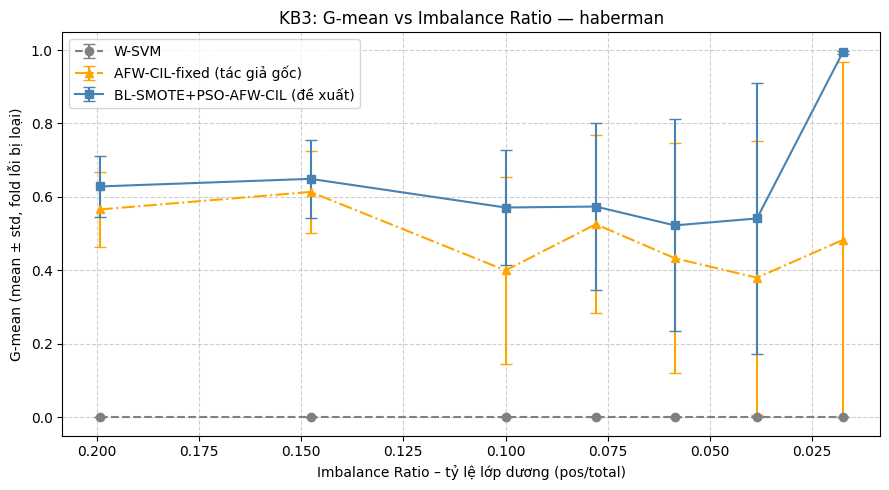

✔ Biểu đồ: ./Experiment/Test_haberman_13032026_003243/Test_haberman_KB3_gmean_vs_ir_13032026_010709.png
✔ KB3 xong. Tổng hợp: ./Experiment/Test_haberman_13032026_003243/Test_haberman_KB3_summary_13032026_010709.csv


In [9]:
# ── Các mức IR cần thử nghiệm ────────────────────────────────
# Haberman: 81 pos / 306 total = 26.5% → chỉ giảm được ≤ 26%
KB3_IR_LIST = [0.20, 0.15, 0.10, 0.08, 0.06, 0.04, 0.02]

def run_kb3(X_all, y_all, run_dir, dataset_name=_DS_BASE, ir_list=None):
    """
    KB3: Stress-test 3 phương pháp trên các biến thể IR giảm dần.
      1. W-SVM           — baseline
      2. AFW-CIL-fixed   — tham số gốc tác giả (σ=1.2)
      3. BL-SMOTE + PSO-AFW-CIL — mô hình đề xuất

    Tối ưu tính toán:
      - AFW-CIL: is_tomek + fuzzy_weight tính 1 lần / fold, dùng lại cho lfb_fixed
      - Proposed: PSO tính ind_posX/negX/init_weight trong __init__ (Fix C)
    Lỗi từng phương pháp được bắt riêng — không dừng toàn bộ câu.
    Ghi float('nan') vào Gm list (bỏ qua khỏi nanmean) và ERROR row vào CSV.
    Trả về: (df_summary, csv_paths_dict)
    """
    if ir_list is None:
        ir_list = KB3_IR_LIST

    ts           = datetime.now().strftime("%d%m%Y_%H%M%S")
    summary_rows = []
    csv_paths    = {}

    def _safe_auc(y_true, y_pred):
        """AUC an toàn khi test set chỉ có 1 class."""
        try:
            return roc_auc_score(y_true, y_pred)
        except ValueError:
            return float('nan')

    print(f"\n{'='*60}")
    print(f"KB3 | Dataset: {dataset_name} | IR list: {ir_list}")
    print(f"So sánh: W-SVM | AFW-CIL-fixed | BL-SMOTE+PSO-AFW-CIL")
    print(f"{'='*60}")

    for ir_target in ir_list:
        ir_pct = int(ir_target * 100)
        print(f"\n[KB3] IR = {ir_target*100:.0f}%  ({ir_target}) ...")

        # ── Tạo biến thể IR ────────────────────────────────────
        try:
            X_ir, y_ir = change_rate_data(X_all, y_all, new_rate=ir_target)
        except Exception as e:
            print(f"  [!] change_rate_data lỗi: {e} → bỏ qua IR={ir_target}")
            continue

        pos_c     = int(np.sum(y_ir == 1.0))
        neg_c     = int(np.sum(y_ir == -1.0))
        actual_ir = pos_c / len(y_ir)
        print(f"  Sau change_rate: {len(y_ir)} mẫu | +1={pos_c} | -1={neg_c} | "
              f"IR_thực={actual_ir:.4f}")

        df_ir          = pd.DataFrame(X_ir)
        df_ir['label'] = y_ir
        ckpt_ir = os.path.join(run_dir, f"Test_{dataset_name}_KB3_IR{ir_pct}pct_data.csv")
        df_ir.to_csv(ckpt_ir, index=False)

        csv_path             = os.path.join(run_dir, f"Test_{dataset_name}_KB3_IR{ir_pct}pct_{ts}.csv")
        csv_paths[ir_target] = csv_path

        min_class       = min(pos_c, neg_c)
        n_splits_actual = min(N_SPLITS, min_class)
        if n_splits_actual < 2:
            print(f"  [!] Quá ít mẫu lớp thiểu số ({min_class}) → bỏ qua toàn bộ IR này")
            continue

        # NaN (không phải 0.0) dùng cho lỗi → nanmean/nanstd sẽ bỏ qua tự động
        wsvm_gm_list, afw_gm_list, proposed_gm_list = [], [], []
        skipped_folds = 0

        for rep in range(1, N_REPEATS + 1):
            skf = StratifiedKFold(n_splits=n_splits_actual,
                                   shuffle=True, random_state=rep * 7)
            for fold, (tr_idx, te_idx) in enumerate(skf.split(X_ir, y_ir), 1):
                X_tr_raw, X_te_raw = X_ir[tr_idx], X_ir[te_idx]
                y_tr, y_te         = y_ir[tr_idx], y_ir[te_idx]

                sc   = StandardScaler()
                X_tr = sc.fit_transform(X_tr_raw)
                X_te = sc.transform(X_te_raw)

                # Guard: fold suy biến — bỏ qua toàn fold khi <2 lớp
                if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
                    print(f"    [!] Rep {rep:02d} | Fold {fold} | <2 lớp → bỏ qua fold")
                    skipped_folds += 1
                    continue

                # ── 1. W-SVM baseline ──────────────────────────────────
                t0 = time.time()
                try:
                    pred_b = wsvm(C, X_tr, y_tr, X_te, np.ones(len(y_tr)))
                    if np.any(np.isnan(pred_b)):
                        raise ValueError("NaN in W-SVM pred")
                    sp_b, se_b, gm_b = Gmean(y_te, pred_b)
                    wsvm_gm_list.append(gm_b)
                    append_csv_row(csv_path, make_row(
                        rep, fold, round(time.time()-t0, 4),
                        "W-SVM", f"IR={ir_target}",
                        sp_b, se_b, gm_b,
                        f1_score(y_te, pred_b, pos_label=1, zero_division=0),
                        accuracy_score(y_te, pred_b), _safe_auc(y_te, pred_b),
                        str(confusion_matrix(y_te, pred_b, labels=[-1., 1.]).tolist())))
                except Exception as e:
                    print(f"    [!] W-SVM lỗi Rep {rep:02d} Fold {fold}: {e} → ghi NaN")
                    wsvm_gm_list.append(float('nan'))   # NaN: không nhiễm nanmean
                    append_csv_row(csv_path, make_row(
                        rep, fold, round(time.time()-t0, 4),
                        "W-SVM", f"ERROR,IR={ir_target}",
                        0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))

                # ── 2. AFW-CIL-fixed (tác giả gốc, σ=FIXED_RATE=1.2) ──
                # is_tomek + fuzzy_weight tính 1 lần / fold → dùng lại cho lfb_fixed
                t0 = time.time()
                try:
                    _, posX_f, negX_f = is_tomek(X_tr, y_tr, class_type=[-1.0])
                    w_init_afw = fuzzy_weight(0.5, 0.8, 0.2, X_tr, y_tr,
                                             NAMEMETHOD, NAMEFUNCTION)
                    if np.any(np.isnan(w_init_afw)) or np.any(w_init_afw <= 0):
                        w_init_afw = np.ones(len(y_tr))   # fallback khi IR quá thấp
                    best_w_afw, _, _ = lfb_fixed(C, posX_f, negX_f, w_init_afw,
                                                  T_INNER, X_te, y_te, X_tr, y_tr)
                    pred_afw = wsvm(C, X_tr, y_tr, X_te, best_w_afw)
                    if np.any(np.isnan(pred_afw)):
                        raise ValueError("NaN in AFW-CIL pred")
                    sp_a, se_a, gm_a = Gmean(y_te, pred_afw)
                    afw_gm_list.append(gm_a)
                    append_csv_row(csv_path, make_row(
                        rep, fold, round(time.time()-t0, 4),
                        "AFW-CIL_fixed", f"sigma=1.2,IR={ir_target}",
                        sp_a, se_a, gm_a,
                        f1_score(y_te, pred_afw, pos_label=1, zero_division=0),
                        accuracy_score(y_te, pred_afw), _safe_auc(y_te, pred_afw),
                        str(confusion_matrix(y_te, pred_afw, labels=[-1., 1.]).tolist())))
                except Exception as e:
                    print(f"    [!] AFW-CIL-fixed lỗi Rep {rep:02d} Fold {fold}: {e} → ghi NaN")
                    afw_gm_list.append(float('nan'))    # NaN: không nhiễm nanmean
                    append_csv_row(csv_path, make_row(
                        rep, fold, round(time.time()-t0, 4),
                        "AFW-CIL_fixed", f"ERROR,IR={ir_target}",
                        0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))

                # ── 3. BL-SMOTE + PSO-AFW-CIL (đề xuất) ──────────────
                # SMOTE trước → PSO_AFWCIL tính is_tomek+fuzzy_weight trong __init__
                # Fix C: dùng pso2.ind_posX / pso2.ind_negX / pso2.init_weight sau optimize()
                t0 = time.time()
                try:
                    sm               = BorderlineSMOTE(random_state=rep)
                    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)[:2]
                    pso2 = PSO_AFWCIL(PSO_PARTICLES, PSO_ITERS, BOUNDS, C, T_INNER,
                                      X_tr_sm, y_tr_sm, X_te, y_te,
                                      NAMEMETHOD, NAMEFUNCTION)
                    gbpos2, gbval2, _ = pso2.optimize()
                    K_b2   = int(round(float(gbpos2[0])))
                    best_w2, _ = lfb_pso(C, pso2.ind_posX, pso2.ind_negX, pso2.init_weight,
                                          T_INNER, X_te, y_te, X_tr_sm, y_tr_sm,
                                          K_b2, gbpos2[1], gbpos2[2], gbpos2[3], gbpos2[4])
                    pred_p = wsvm(C, X_tr_sm, y_tr_sm, X_te, best_w2)
                    if np.any(np.isnan(pred_p)):
                        raise ValueError("NaN in proposed pred")
                    sp_p, se_p, gm_p = Gmean(y_te, pred_p)
                    proposed_gm_list.append(gm_p)
                    fn_str2 = (f"K={K_b2},s1={gbpos2[1]:.3f},s2={gbpos2[2]:.3f},"
                               f"s3={gbpos2[3]:.3f},s4={gbpos2[4]:.3f}")
                    append_csv_row(csv_path, make_row(
                        rep, fold, round(time.time()-t0, 4),
                        "BL-SMOTE+PSO-AFW-CIL", fn_str2,
                        sp_p, se_p, gm_p,
                        f1_score(y_te, pred_p, pos_label=1, zero_division=0),
                        accuracy_score(y_te, pred_p), _safe_auc(y_te, pred_p),
                        str(confusion_matrix(y_te, pred_p, labels=[-1., 1.]).tolist())))
                except Exception as e:
                    print(f"    [!] BL-SMOTE+PSO lỗi Rep {rep:02d} Fold {fold}: {e} → ghi NaN")
                    proposed_gm_list.append(float('nan'))  # NaN: không nhiễm nanmean
                    append_csv_row(csv_path, make_row(
                        rep, fold, round(time.time()-t0, 4),
                        "BL-SMOTE+PSO-AFW-CIL", f"ERROR,IR={ir_target}",
                        0.0, 0.0, 0.0, 0.0, 0.0, float('nan'), "error"))

            print(f"  IR={ir_target*100:.0f}% | Rep {rep:02d} ✓")

        if skipped_folds > 0:
            print(f"  [i] Tổng fold bỏ qua do suy biến: {skipped_folds}")

        # nanmean/nanstd tự động bỏ qua float('nan') — không bị nhiễm bởi fold lỗi
        def _stat(lst):
            arr = [x for x in lst if x == x]   # bỏ NaN (nan != nan)
            if not arr:
                return float('nan'), 0.0
            return round(float(np.nanmean(arr)), 4), round(float(np.nanstd(arr)), 4)

        wsvm_mean, wsvm_std  = _stat(wsvm_gm_list)
        afw_mean,  afw_std   = _stat(afw_gm_list)
        prop_mean, prop_std  = _stat(proposed_gm_list)

        n_wsvm_ok  = sum(1 for x in wsvm_gm_list     if x == x)
        n_afw_ok   = sum(1 for x in afw_gm_list      if x == x)
        n_prop_ok  = sum(1 for x in proposed_gm_list  if x == x)
        n_total    = len(wsvm_gm_list)
        print(f"  Tỷ lệ thành công: W-SVM={n_wsvm_ok}/{n_total} | "
              f"AFW={n_afw_ok}/{n_total} | Proposed={n_prop_ok}/{n_total}")

        summary_rows.append({
            "IR_target":        ir_target,
            "IR_actual":        round(actual_ir, 4),
            "n_samples":        len(y_ir),
            "pos_count":        pos_c,
            "n_folds_ok":       n_total,
            "WSVM_ok":          n_wsvm_ok,
            "AFW_ok":           n_afw_ok,
            "Proposed_ok":      n_prop_ok,
            "WSVM_Gm_mean":     wsvm_mean,
            "WSVM_Gm_std":      wsvm_std,
            "AFW_Gm_mean":      afw_mean,
            "AFW_Gm_std":       afw_std,
            "Proposed_Gm_mean": prop_mean,
            "Proposed_Gm_std":  prop_std,
        })

    # ── Tổng hợp KB3 ─────────────────────────────────────────
    df_sum3  = pd.DataFrame(summary_rows)
    sum_path = os.path.join(run_dir, f"Test_{dataset_name}_KB3_summary_{ts}.csv")
    df_sum3.to_csv(sum_path, index=False)

    print(f"\n{'='*60}")
    print("BẢNG TỔNG KẾT KB3 (G-mean mean ± std, chỉ tính fold thành công)")
    cols_show = [c for c in ["IR_target", "WSVM_ok", "AFW_ok", "Proposed_ok",
                              "WSVM_Gm_mean", "AFW_Gm_mean", "Proposed_Gm_mean"] if c in df_sum3.columns]
    print(df_sum3[cols_show].to_string(index=False))

    # ── Biểu đồ G-mean vs IR (3 đường) ──────────────────────
    if len(df_sum3) > 0:
        _, ax = plt.subplots(figsize=(9, 5))
        x     = df_sum3["IR_actual"]
        ax.errorbar(x, df_sum3["WSVM_Gm_mean"],
                    yerr=df_sum3["WSVM_Gm_std"].fillna(0),
                    marker='o', label='W-SVM',
                    capsize=4, linestyle='--', color='gray')
        ax.errorbar(x, df_sum3["AFW_Gm_mean"],
                    yerr=df_sum3["AFW_Gm_std"].fillna(0),
                    marker='^', label='AFW-CIL-fixed (tác giả gốc)',
                    capsize=4, linestyle='-.', color='orange')
        ax.errorbar(x, df_sum3["Proposed_Gm_mean"],
                    yerr=df_sum3["Proposed_Gm_std"].fillna(0),
                    marker='s', label='BL-SMOTE+PSO-AFW-CIL (đề xuất)',
                    capsize=4, color='steelblue')
        ax.set_xlabel("Imbalance Ratio – tỷ lệ lớp dương (pos/total)")
        ax.set_ylabel("G-mean (mean ± std, fold lỗi bị loại)")
        ax.set_title(f"KB3: G-mean vs Imbalance Ratio — {dataset_name}")
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.invert_xaxis()   # từ cao → thấp (stress tăng dần)
        plt.tight_layout()
        plot_path = os.path.join(run_dir, f"Test_{dataset_name}_KB3_gmean_vs_ir_{ts}.png")
        plt.savefig(plot_path, dpi=150)
        plt.show()
        print(f"✔ Biểu đồ: {plot_path}")

    print(f"✔ KB3 xong. Tổng hợp: {sum_path}")
    return df_sum3, csv_paths


# ── Chạy KB3 ─────────────────────────────────────────────────
df_kb3_sum, csv_kb3_dict = run_kb3(X_all, y_all, RUN_DIR)


---
## Tổng hợp Kết quả & Trực quan hoá


Thư mục: ./Experiment/Test_haberman_13032026_003243
Files CSV kịch bản:
  Test_haberman_KB1_13032026_003326.csv
  Test_haberman_KB2_13032026_004501.csv
  Test_haberman_KB3_IR10pct_13032026_010709.csv
  Test_haberman_KB3_IR15pct_13032026_010709.csv
  Test_haberman_KB3_IR20pct_13032026_010709.csv
  Test_haberman_KB3_IR2pct_13032026_010709.csv
  Test_haberman_KB3_IR4pct_13032026_010709.csv
  Test_haberman_KB3_IR6pct_13032026_010709.csv
  Test_haberman_KB3_IR8pct_13032026_010709.csv

Tổng kết: Test_haberman_KB1_13032026_003326


,Name Method,Gmean_mean,Gmean_std,AUC_mean
0,AFW-CIL_fixed,0.585358,0.084191,0.633490
1,GridSearch-AFW-CIL,0.581460,0.082616,0.631372
2,PSO-AFW-CIL,0.562680,0.141183,0.629222
3,W-SVM,0.333718,0.258026,0.561476


✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB1_13032026_003326_Gmean.png


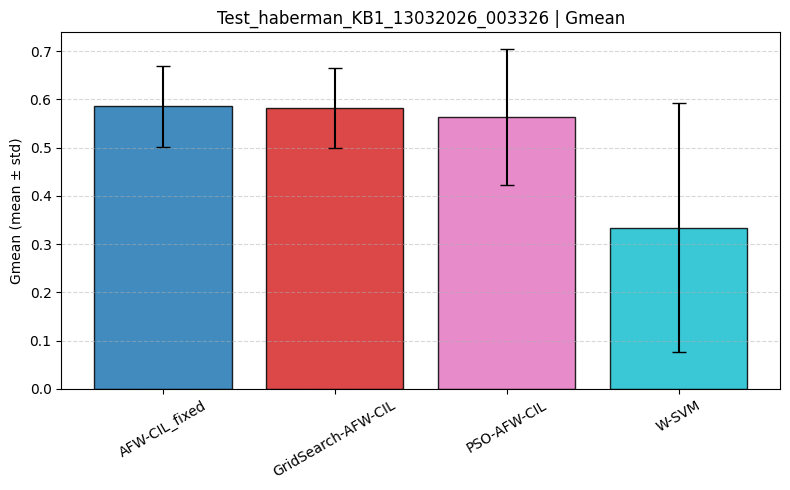

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB1_13032026_003326_AUC.png


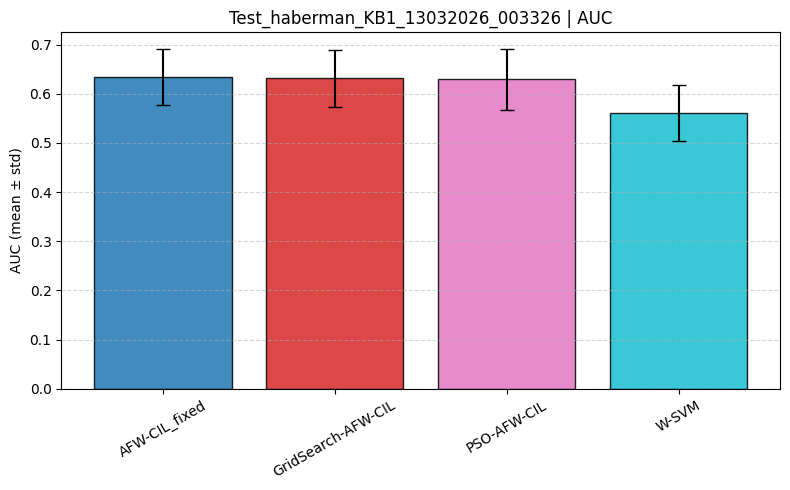

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB1_13032026_003326_F1_Score.png


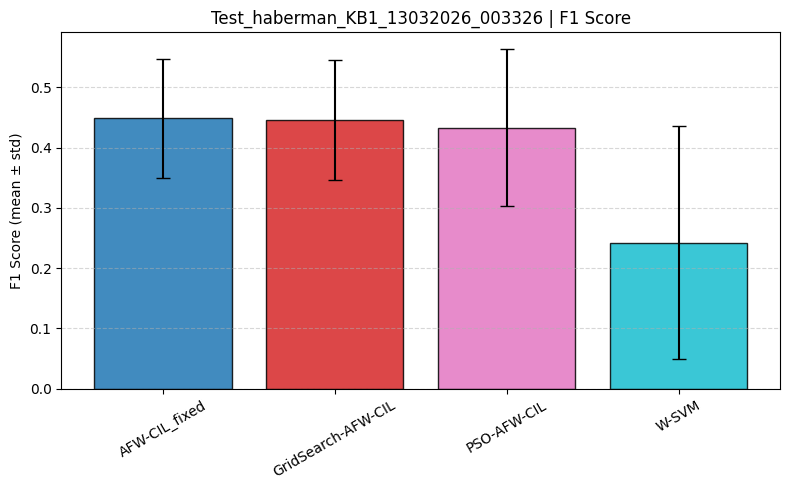


Tổng kết: Test_haberman_KB2_13032026_004501


,Name Method,Gmean_mean,Gmean_std,AUC_mean
0,AFW-CIL_fixed,0.585358,0.084191,0.633490
1,BL-SMOTE+AFW-CIL_fixed,0.598898,0.073376,0.611670
2,BL-SMOTE+PSO-AFW-CIL,0.621228,0.078737,0.631592
3,BL-SMOTE+W-SVM,0.620628,0.080377,0.636850
4,PSO-AFW-CIL,0.532928,0.212190,0.631104
5,W-SVM,0.333718,0.258026,0.561476


✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB2_13032026_004501_Gmean.png


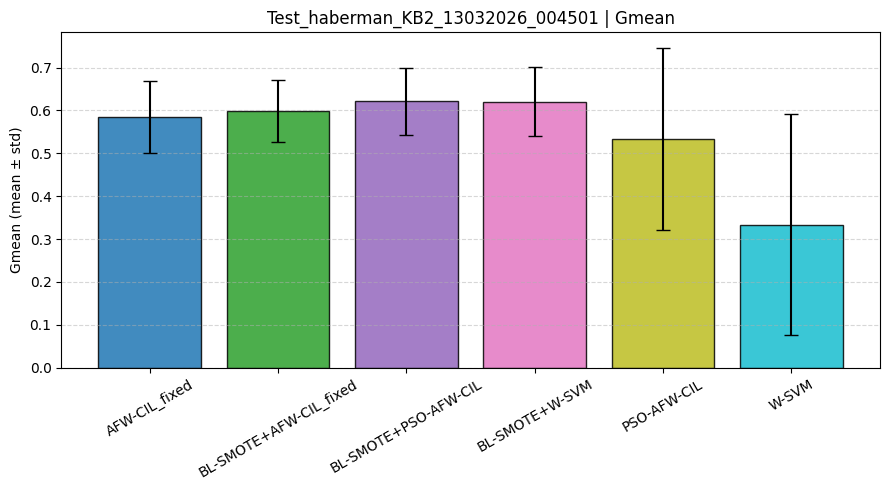

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB2_13032026_004501_AUC.png


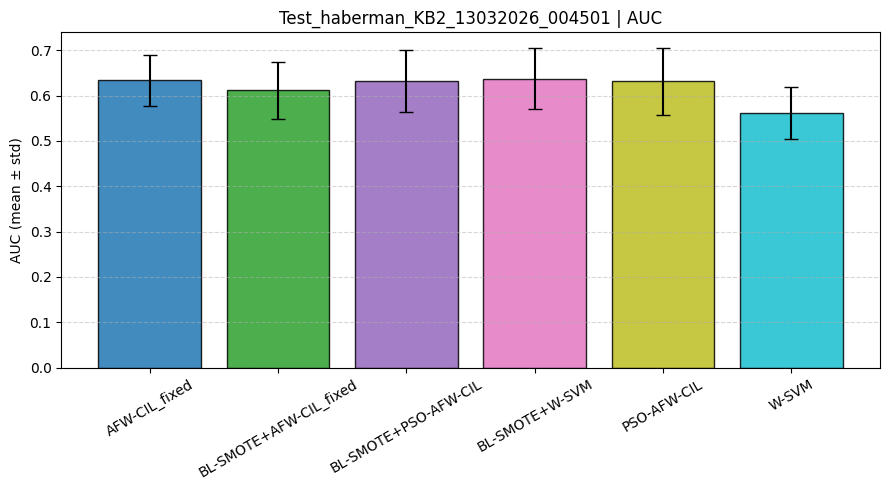

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB2_13032026_004501_F1_Score.png


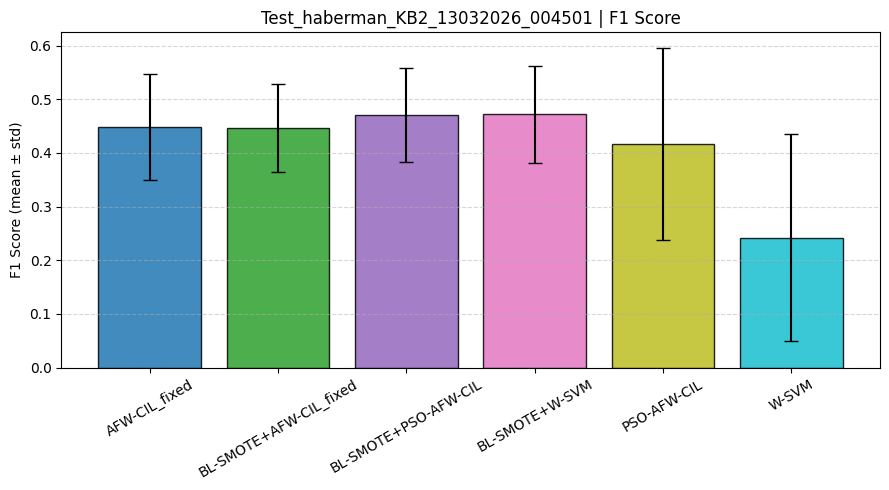


Tổng kết: Test_haberman_KB3_IR10pct_13032026_010709


,Name Method,Gmean_mean,Gmean_std,AUC_mean
0,AFW-CIL_fixed,0.399956,0.258269,0.581788
1,BL-SMOTE+PSO-AFW-CIL,0.571332,0.159304,0.607338
2,W-SVM,0.000000,0.000000,0.500000


✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR10pct_13032026_010709_Gmean.png


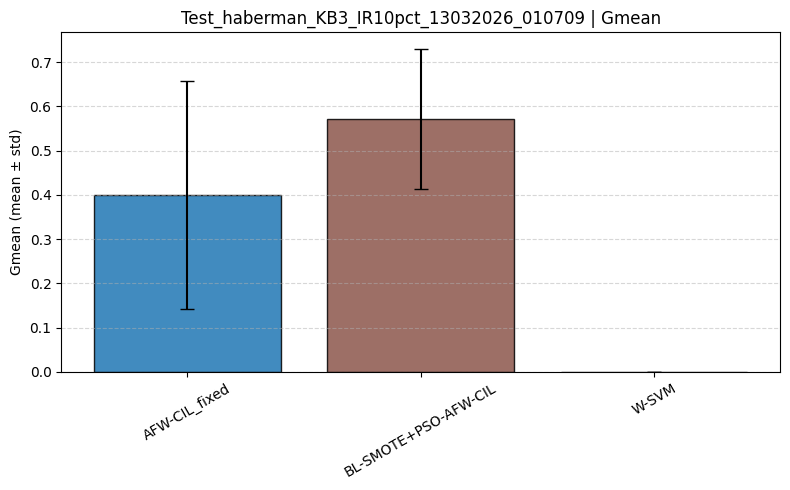

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR10pct_13032026_010709_AUC.png


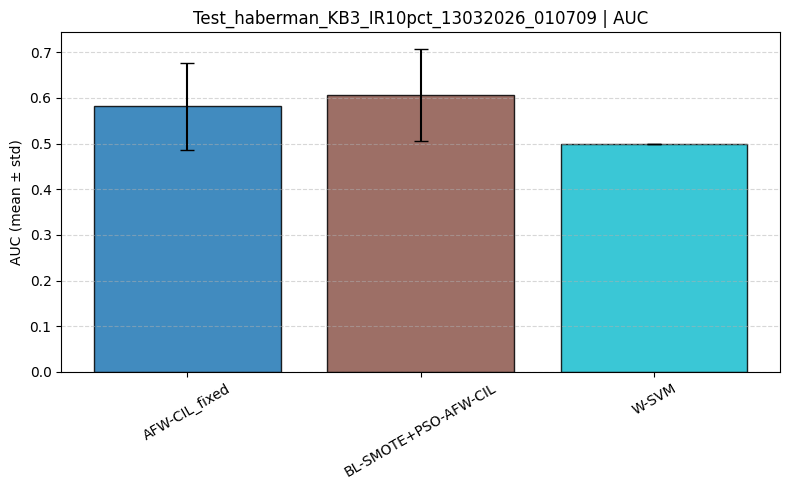

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR10pct_13032026_010709_F1_Score.png


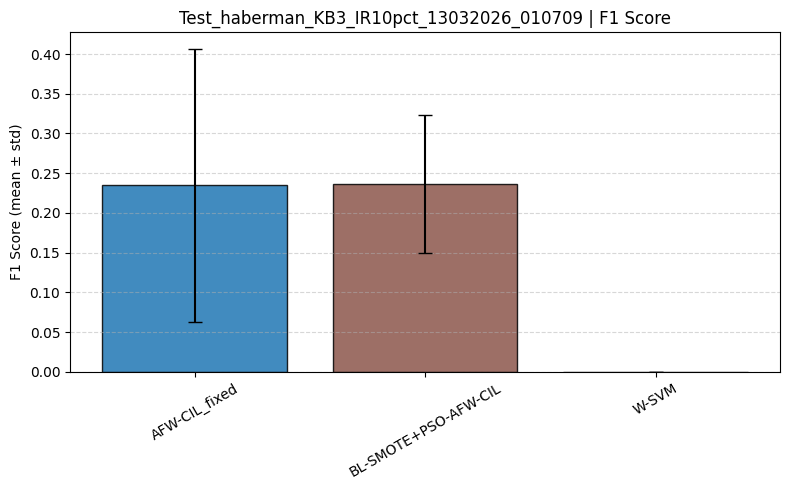


Tổng kết: Test_haberman_KB3_IR15pct_13032026_010709


,Name Method,Gmean_mean,Gmean_std,AUC_mean
0,AFW-CIL_fixed,0.613730,0.11283,0.663944
1,BL-SMOTE+PSO-AFW-CIL,0.649282,0.10692,0.672734
2,W-SVM,0.000000,0.00000,0.500000


✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR15pct_13032026_010709_Gmean.png


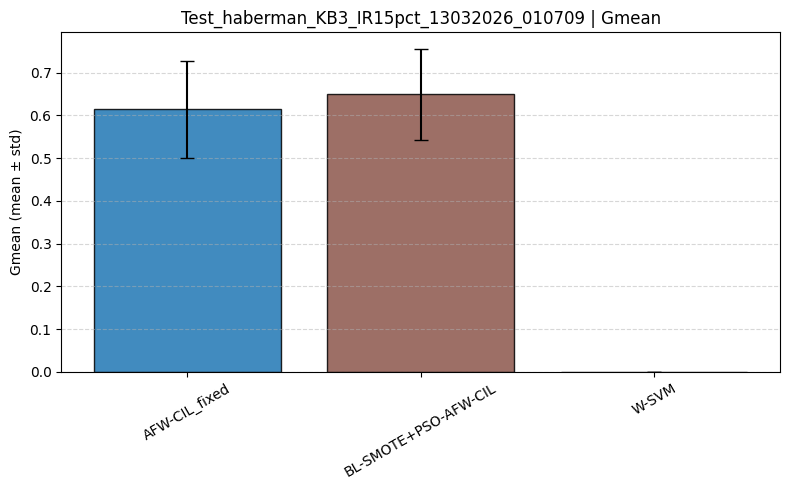

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR15pct_13032026_010709_AUC.png


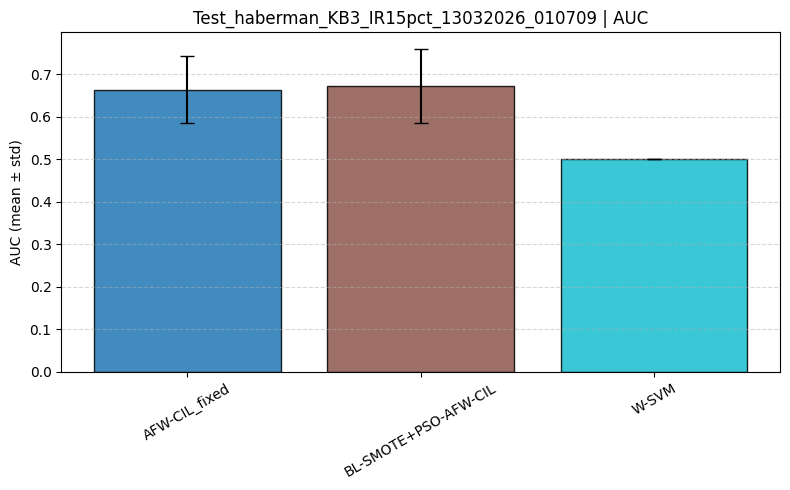

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR15pct_13032026_010709_F1_Score.png


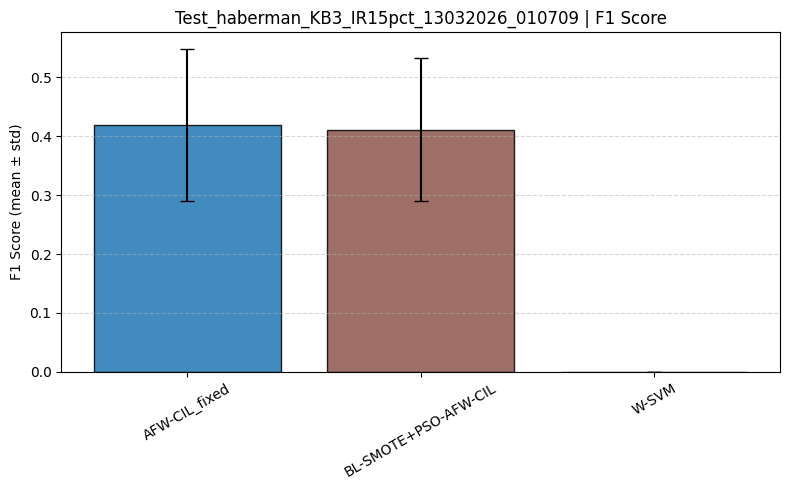


Tổng kết: Test_haberman_KB3_IR20pct_13032026_010709


,Name Method,Gmean_mean,Gmean_std,AUC_mean
0,AFW-CIL_fixed,0.565920,0.104056,0.627400
1,BL-SMOTE+PSO-AFW-CIL,0.628588,0.084647,0.639206
2,W-SVM,0.000000,0.000000,0.500000


✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR20pct_13032026_010709_Gmean.png


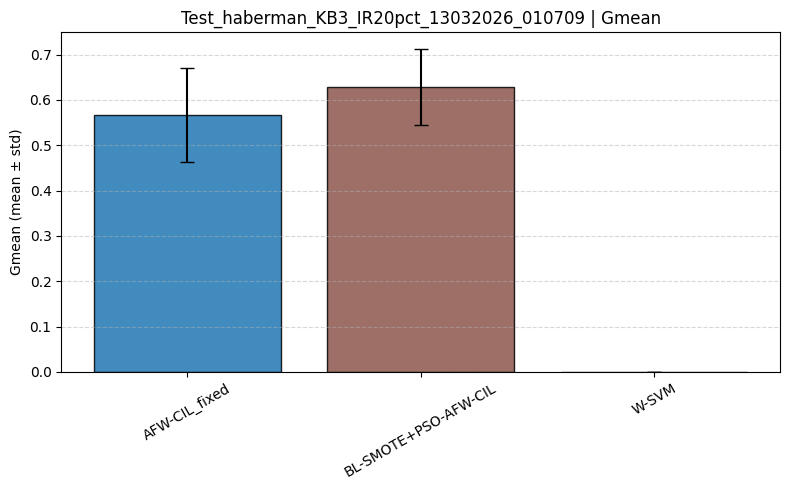

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR20pct_13032026_010709_AUC.png


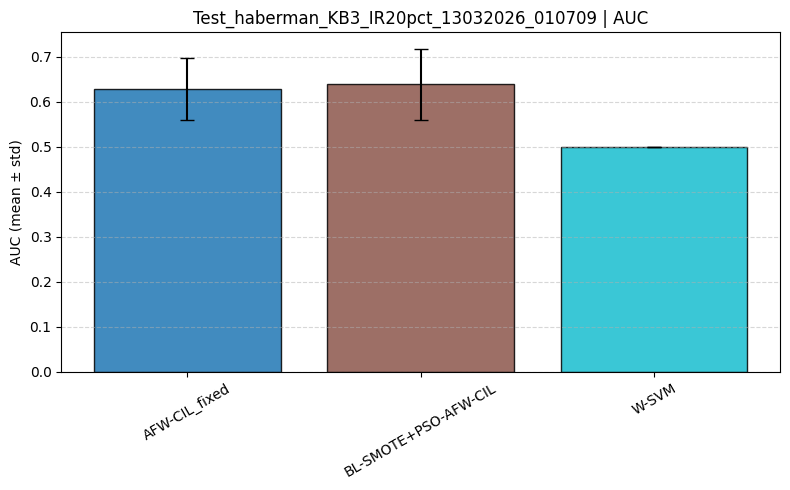

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR20pct_13032026_010709_F1_Score.png


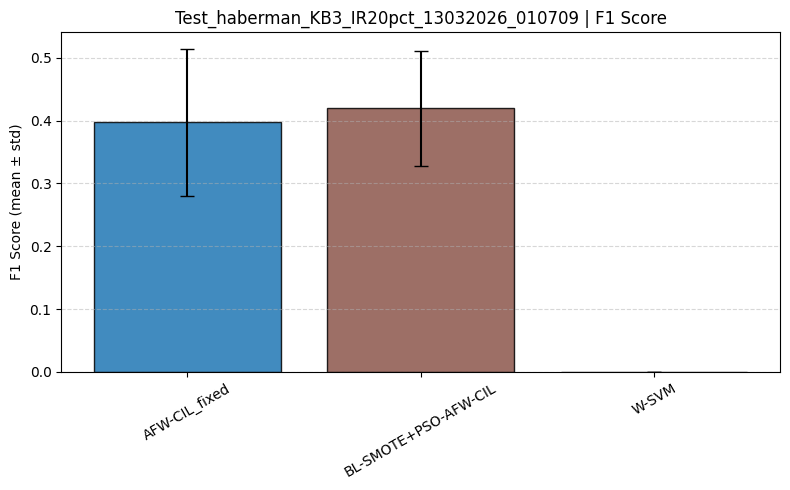


Tổng kết: Test_haberman_KB3_IR2pct_13032026_010709


,Name Method,Gmean_mean,Gmean_std,AUC_mean
0,AFW-CIL_fixed,0.483007,0.489291,0.724917
1,BL-SMOTE+PSO-AFW-CIL,0.074550,0.265149,0.994067
2,W-SVM,0.000000,0.000000,0.500000


✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR2pct_13032026_010709_Gmean.png


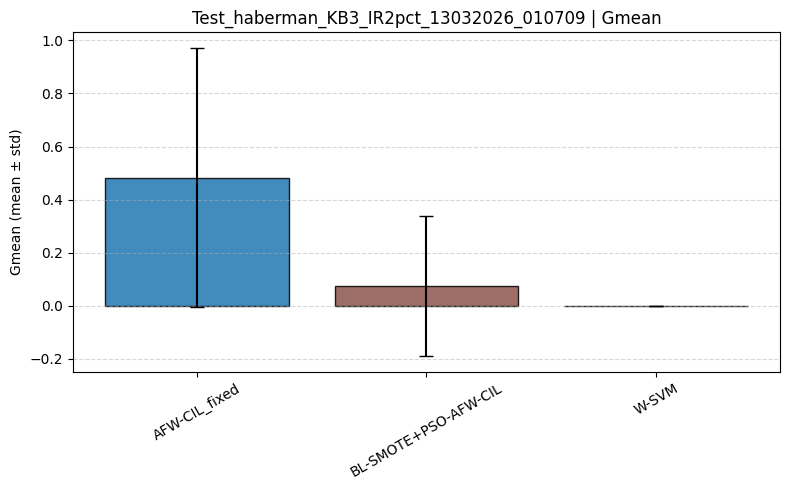

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR2pct_13032026_010709_AUC.png


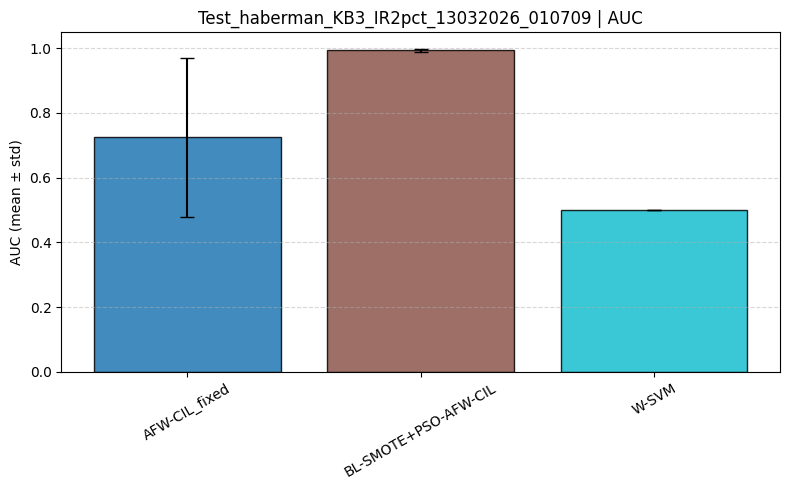

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR2pct_13032026_010709_F1_Score.png


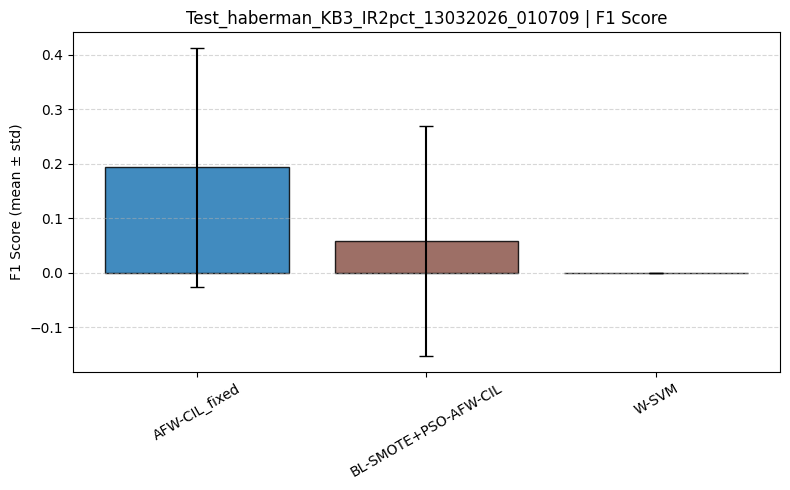


Tổng kết: Test_haberman_KB3_IR4pct_13032026_010709


,Name Method,Gmean_mean,Gmean_std,AUC_mean
0,AFW-CIL_fixed,0.380224,0.376574,0.61946
1,BL-SMOTE+PSO-AFW-CIL,0.541586,0.372240,0.68133
2,W-SVM,0.000000,0.000000,0.50000


✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR4pct_13032026_010709_Gmean.png


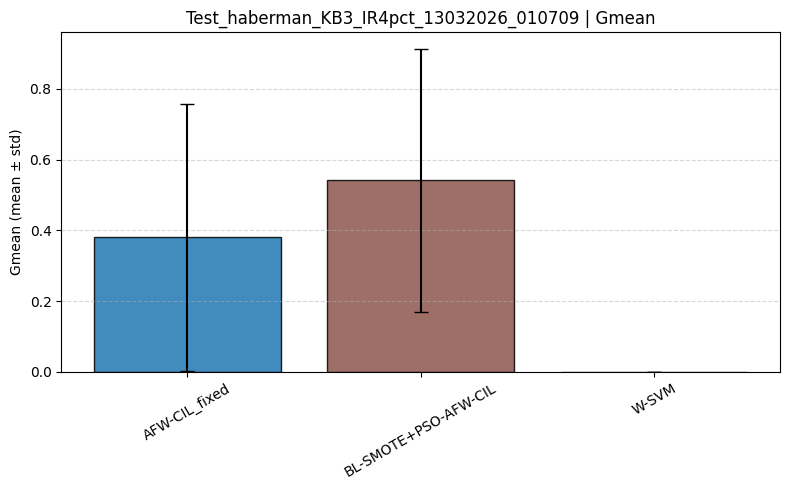

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR4pct_13032026_010709_AUC.png


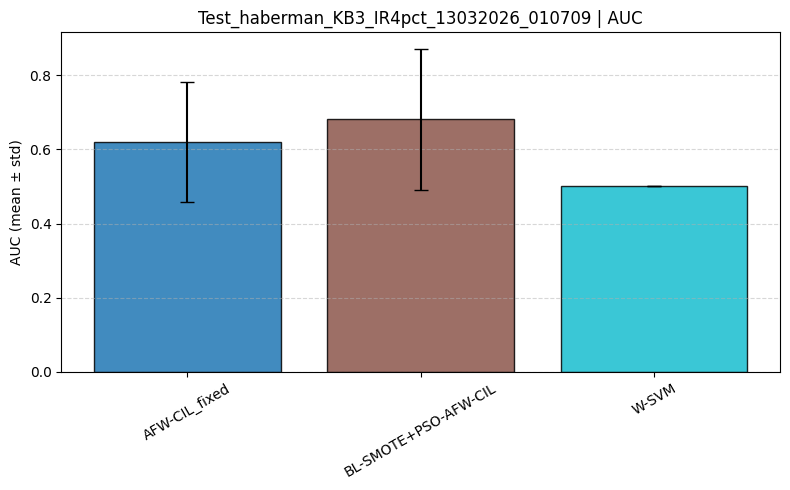

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR4pct_13032026_010709_F1_Score.png


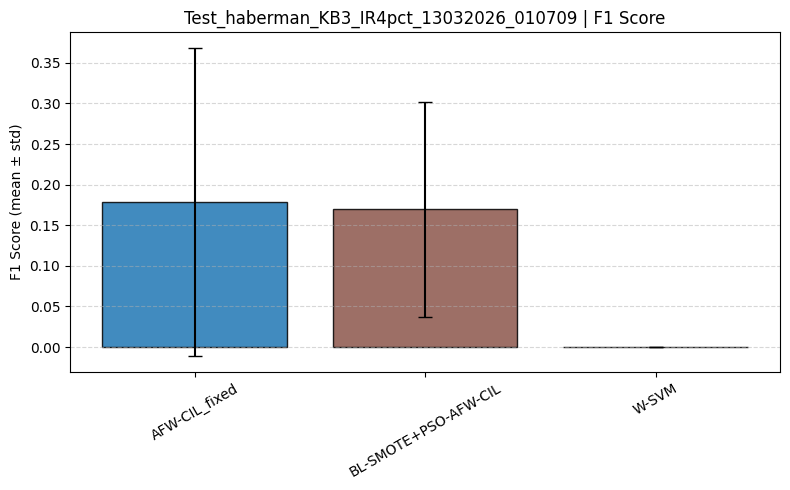


Tổng kết: Test_haberman_KB3_IR6pct_13032026_010709


,Name Method,Gmean_mean,Gmean_std,AUC_mean
0,AFW-CIL_fixed,0.433234,0.315997,0.612446
1,BL-SMOTE+PSO-AFW-CIL,0.522636,0.291666,0.630334
2,W-SVM,0.000000,0.000000,0.500000


✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR6pct_13032026_010709_Gmean.png


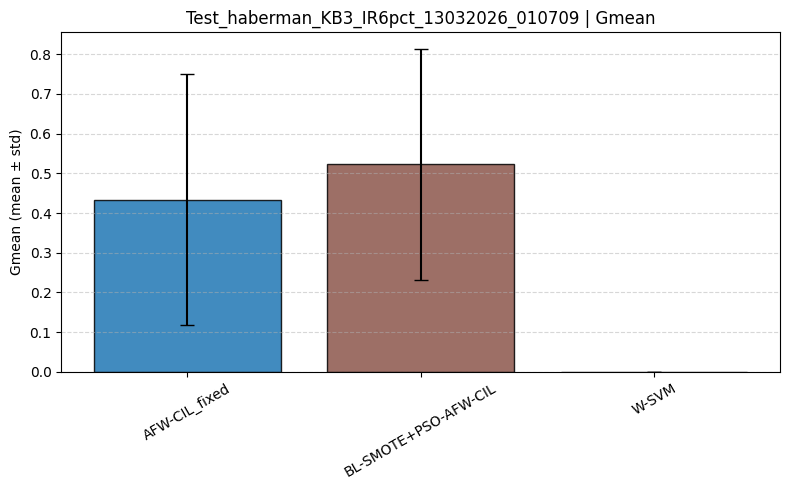

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR6pct_13032026_010709_AUC.png


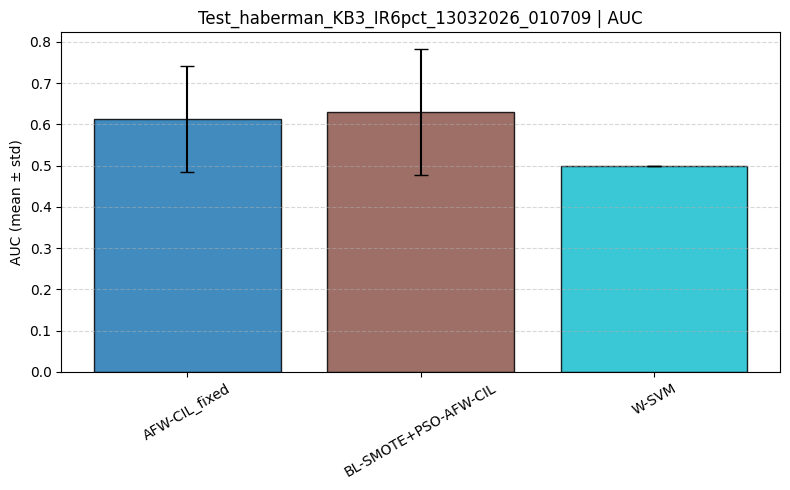

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR6pct_13032026_010709_F1_Score.png


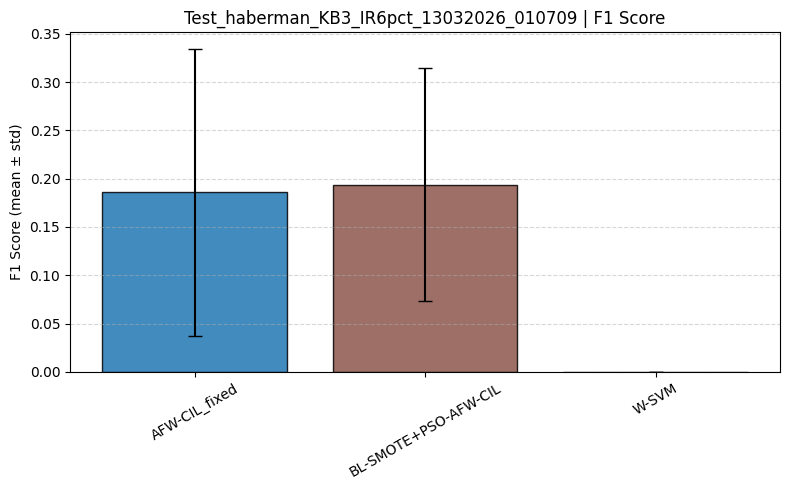


Tổng kết: Test_haberman_KB3_IR8pct_13032026_010709


,Name Method,Gmean_mean,Gmean_std,AUC_mean
0,AFW-CIL_fixed,0.525782,0.244193,0.641454
1,BL-SMOTE+PSO-AFW-CIL,0.573928,0.230716,0.642220
2,W-SVM,0.000000,0.000000,0.500000


✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR8pct_13032026_010709_Gmean.png


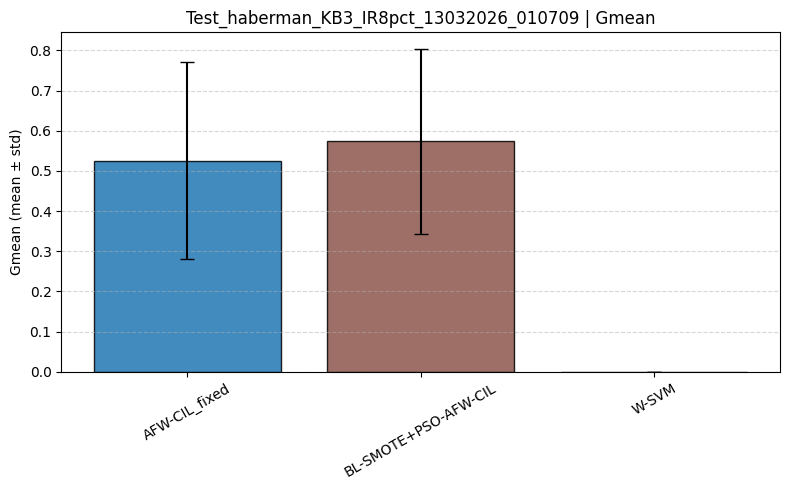

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR8pct_13032026_010709_AUC.png


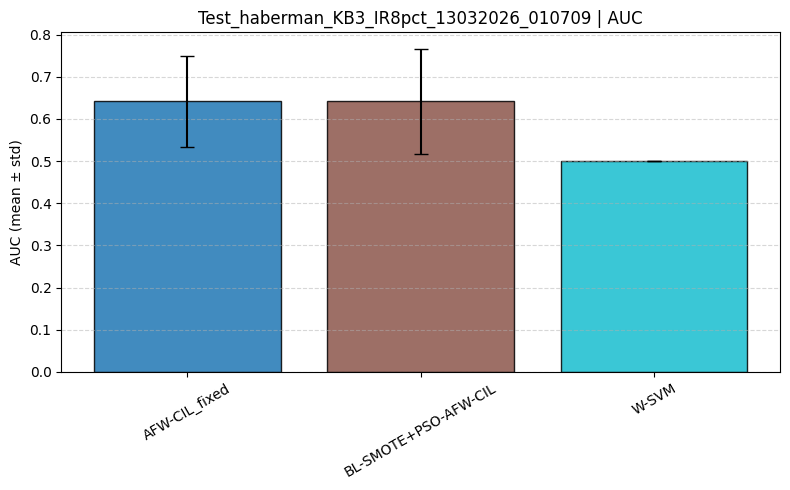

✔ Plot saved: ./Experiment/Test_haberman_13032026_003243/plot_Test_haberman_KB3_IR8pct_13032026_010709_F1_Score.png


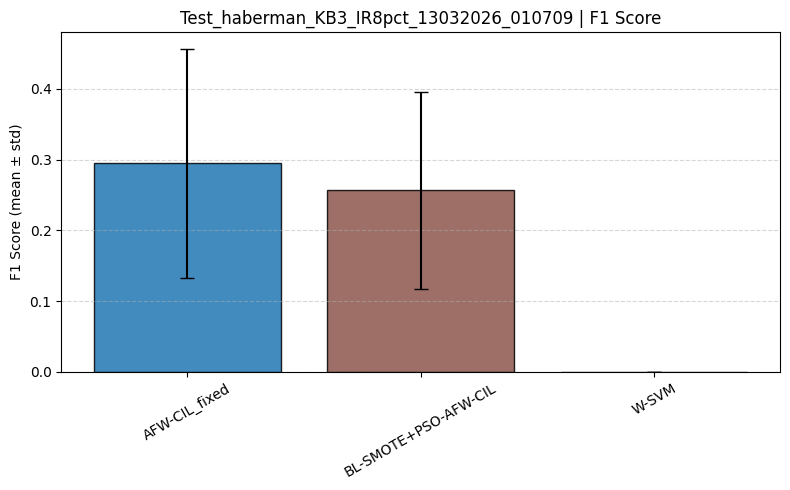



KB3 — STRESS TEST SUMMARY:


,IR_target,IR_actual,n_samples,pos_count,n_folds_ok,WSVM_ok,AFW_ok,Proposed_ok,WSVM_Gm_mean,WSVM_Gm_std,AFW_Gm_mean,AFW_Gm_std,Proposed_Gm_mean,Proposed_Gm_std
0,0.20,0.1993,281,56,50,50,50,50,0.0,0.0,0.5659,0.1030,0.6286,0.0838
1,0.15,0.1477,264,39,50,50,50,50,0.0,0.0,0.6137,0.1117,0.6493,0.1058
2,0.10,0.1000,250,25,50,50,50,50,0.0,0.0,0.4000,0.2557,0.5713,0.1577
3,0.08,0.0779,244,19,50,50,50,50,0.0,0.0,0.5258,0.2417,0.5739,0.2284
4,0.06,0.0586,239,14,50,50,50,50,0.0,0.0,0.4332,0.3128,0.5226,0.2887
5,0.04,0.0385,234,9,50,50,50,50,0.0,0.0,0.3802,0.3728,0.5416,0.3685
6,0.02,0.0175,229,4,40,40,40,3,0.0,0.0,0.4830,0.4831,0.9940,0.0042



✔ Tất cả kết quả trong: ./Experiment/Test_haberman_13032026_003243
Contents:
  Test_haberman_KB1_13032026_003326.csv                            20997 bytes
  Test_haberman_KB1_summary_13032026_003326.csv                      762 bytes
  Test_haberman_KB2_13032026_004501.csv                            33398 bytes
  Test_haberman_KB2_rep01_checkpoint.csv                            3419 bytes
  Test_haberman_KB2_rep02_checkpoint.csv                            6751 bytes
  Test_haberman_KB2_rep03_checkpoint.csv                           10092 bytes
  Test_haberman_KB2_rep04_checkpoint.csv                           13427 bytes
  Test_haberman_KB2_rep05_checkpoint.csv                           16752 bytes
  Test_haberman_KB2_rep06_checkpoint.csv                           20079 bytes
  Test_haberman_KB2_rep07_checkpoint.csv                           23423 bytes
  Test_haberman_KB2_rep08_checkpoint.csv                           26722 bytes
  Test_haberman_KB2_rep09_checkpoint.csv             

In [10]:
def compute_average_result(csv_path, metrics=None):
    """Đọc CSV → tính mean±std theo 'Name Method'."""
    if metrics is None:
        metrics = ['SP', 'SE', 'Gmean', 'F1 Score', 'Accuracy', 'AUC']
    df = pd.read_csv(csv_path)
    for m in metrics:
        df[m] = pd.to_numeric(df[m], errors='coerce')
    agg = {}
    for m in metrics:
        agg[f"{m}_mean"] = (m, 'mean')
        agg[f"{m}_std"]  = (m, 'std')
    return df.groupby("Name Method").agg(**agg).reset_index()


def plot_comparison(summary_df, metric="Gmean",
                    title="So sánh phương pháp", save_path=None):
    """Biểu đồ cột mean ± std cho từng phương pháp."""
    mean_col = f"{metric}_mean"
    std_col  = f"{metric}_std"
    _, ax = plt.subplots(figsize=(max(8, len(summary_df) * 1.5), 5))
    colors = plt.colormaps['tab10'](np.linspace(0, 1, len(summary_df)))
    ax.bar(summary_df["Name Method"], summary_df[mean_col],
           yerr=summary_df[std_col],
           color=colors, alpha=0.85, capsize=5, edgecolor='black')
    ax.set_ylabel(f"{metric} (mean ± std)")
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"✔ Plot saved: {save_path}")
    plt.show()


# ── Tổng hợp từ tất cả CSV của lần chạy này ──────────────────
all_csvs = sorted(glob.glob(os.path.join(RUN_DIR, "Test_*.csv")))
# Lọc bỏ checkpoint & summary & data
scenario_csvs = [f for f in all_csvs
                 if "checkpoint" not in f and "summary" not in f and "data" not in f]

print(f"\nThư mục: {RUN_DIR}")
print(f"Files CSV kịch bản:")
for f in scenario_csvs:
    print(f"  {os.path.basename(f)}")

# ── Vẽ biểu đồ cho từng kịch bản ────────────────────────────
for csv_f in scenario_csvs:
    name = os.path.basename(csv_f).replace(".csv", "")
    try:
        s = compute_average_result(csv_f)
        print(f"\n{'='*55}")
        print(f"Tổng kết: {name}")
        display(s[["Name Method", "Gmean_mean", "Gmean_std", "AUC_mean"]])
        for metric in ["Gmean", "AUC", "F1 Score"]:
            save_p = os.path.join(RUN_DIR, f"plot_{name}_{metric.replace(' ','_')}.png")
            plot_comparison(s, metric=metric,
                            title=f"{name} | {metric}",
                            save_path=save_p)
    except Exception as e:
        print(f"[!] Không thể vẽ {name}: {e}")

# ── Hiển thị tổng kết KB3 ────────────────────────────────────
if 'df_kb3_sum' in dir() and len(df_kb3_sum) > 0:
    print("\n\nKB3 — STRESS TEST SUMMARY:")
    display(df_kb3_sum)

print(f"\n✔ Tất cả kết quả trong: {RUN_DIR}")
print("Contents:")
for f in sorted(os.listdir(RUN_DIR)):
    fpath = os.path.join(RUN_DIR, f)
    size  = os.path.getsize(fpath) if os.path.isfile(fpath) else 0
    print(f"  {f:<60}  {size:>8} bytes")
